# Taller: Diseño y Optimización de un MLP Profundo

**Curso:** Técnicas de Inteligencia Artificial  
**Universidad Nacional de Colombia — Sede Bogotá**  
**Ingeniería Mecatrónica — Facultad de Ingeniería**  
**Profesor:** Flavio Prieto — faprietoo@unal.edu.co  
**Estudiantes** Sergio Andrés Bolaños Penagos, Jorge Nicolas Garzon Acevedo, David Santiago Pirateque Suarez  
**Fecha:** Abril 2026

---

## Objetivo

Diseñar, entrenar y optimizar un Perceptrón Multicapa (MLP) para identificar personas
en un problema de clasificación multiclase usando el dataset **Olivetti Faces** (40 clases, 400 imágenes).


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, f1_score)
from torch.utils.data import DataLoader, TensorDataset
import time, copy, warnings, math, pandas as pd

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cpu")
print(f"Dispositivo: {DEVICE}")
print(f"PyTorch:     {torch.__version__}")

# Version extendida: 30 trials completos y 10 candidatos re-entrenados.
# Para una corrida rapida, cambiar VERSION a "rapida".
VERSION       = "extendida"
N_TRIALS      = 30 if VERSION == "extendida" else 12
MAX_EPOCHS    = 60 if VERSION == "extendida" else 40
PATIENCE      = 6 if VERSION == "extendida" else 5
N_CANDIDATES  = 10 if VERSION == "extendida" else 8
RETRAIN_EPOCHS = 80 if VERSION == "extendida" else 50
CANDIDATE_PATIENCE = 8 if VERSION == "extendida" else 5
USE_PRUNER    = False

print()
print(f"Versión: {VERSION} | Trials: {N_TRIALS} | "
      f"Épocas máx/trial: {MAX_EPOCHS} | Patience: {PATIENCE} | "
      f"Candidatos a re-entrenar: {N_CANDIDATES} | "
      f"Patience candidatos: {CANDIDATE_PATIENCE}")
print(f"Pruning activado: {USE_PRUNER}")


Dispositivo: cpu
PyTorch:     2.11.0+cu130

Versión: extendida | Trials: 30 | Épocas máx/trial: 60 | Patience: 6 | Candidatos a re-entrenar: 10 | Patience candidatos: 8
Pruning activado: False


---
## Parte 1 — Preprocesamiento

### 1.1 Carga del dataset Olivetti Faces


In [13]:
faces = fetch_olivetti_faces(shuffle=False)
X, y = faces.data, faces.target

print(f"Dimensiones X: {X.shape}  (400 imágenes x 4096 píxeles)")
print(f"Clases:        {len(np.unique(y))} personas")
print(f"Imgs/persona:  {np.bincount(y)[0]}")
print(f"Rango valores: [{X.min():.2f}, {X.max():.2f}]")


Dimensiones X: (400, 4096)  (400 imágenes x 4096 píxeles)
Clases:        40 personas
Imgs/persona:  10
Rango valores: [0.00, 1.00]


### 1.2 Visualización exploratoria

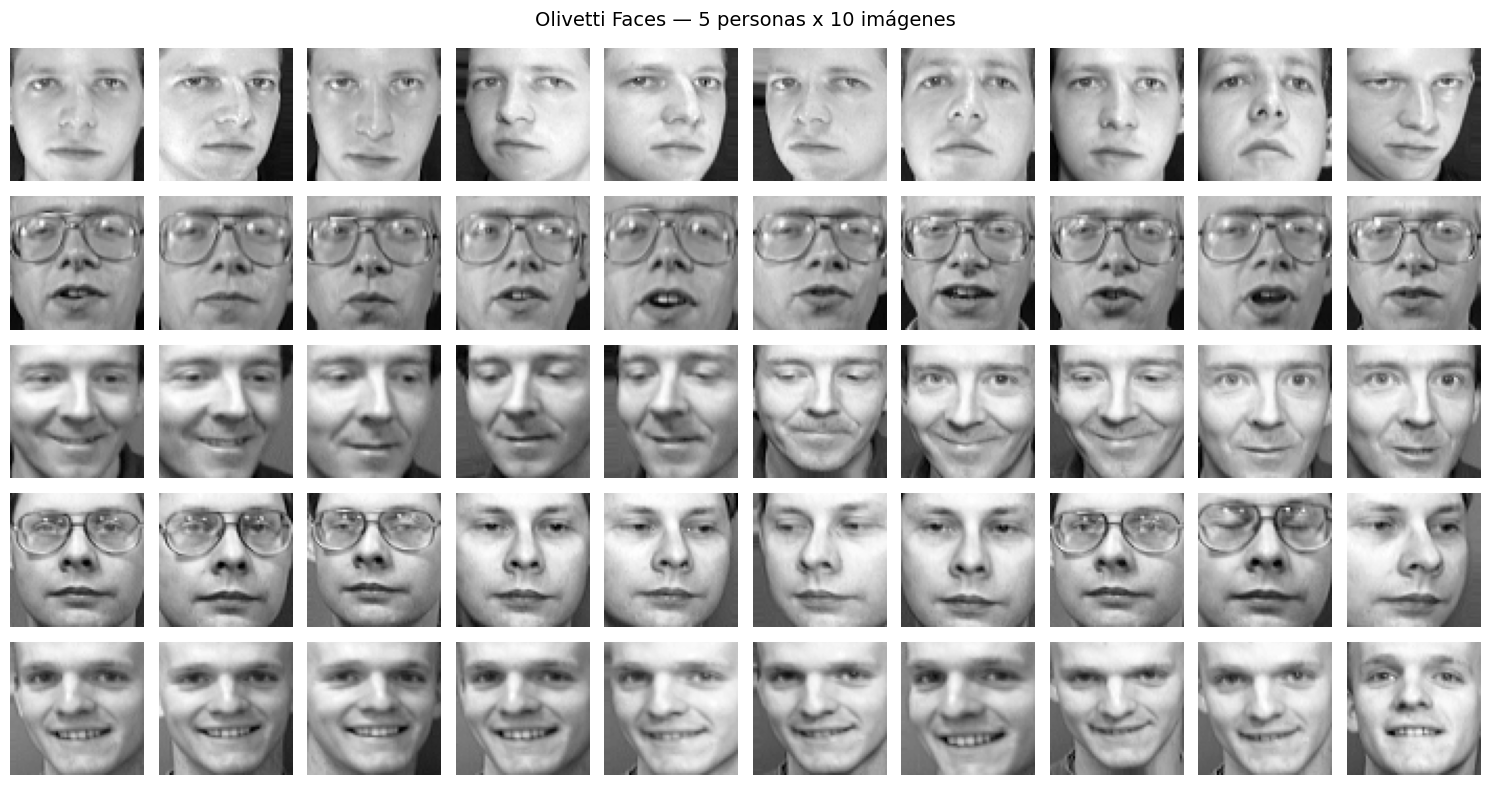

In [14]:
fig, axes = plt.subplots(5, 10, figsize=(15, 8))
fig.suptitle("Olivetti Faces — 5 personas x 10 imágenes", fontsize=14)
for persona in range(5):
    for j, idx in enumerate(np.where(y == persona)[0]):
        axes[persona, j].imshow(faces.images[idx], cmap="gray")
        axes[persona, j].axis("off")
        if j == 0:
            axes[persona, j].set_ylabel(f"P{persona}", fontsize=10)
plt.tight_layout()
plt.savefig("fig_01_faces_grid.png", dpi=150, bbox_inches="tight")
plt.show()


### 1.3 Distribución de clases

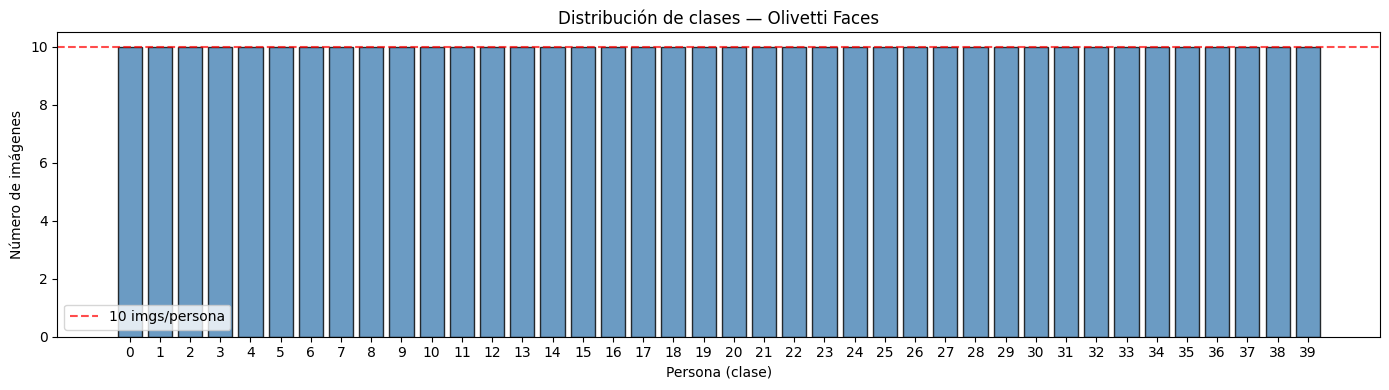

Dataset perfectamente balanceado: True


In [15]:
fig, ax = plt.subplots(figsize=(14, 4))
counts = np.bincount(y)
ax.bar(range(40), counts, color="steelblue", edgecolor="black", alpha=0.8)
ax.set_xlabel("Persona (clase)")
ax.set_ylabel("Número de imágenes")
ax.set_title("Distribución de clases — Olivetti Faces")
ax.set_xticks(range(40))
ax.axhline(y=10, color="red", linestyle="--", alpha=0.7, label="10 imgs/persona")
ax.legend()
plt.tight_layout()
plt.savefig("fig_02_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Dataset perfectamente balanceado: {bool(np.all(counts == 10))}")


### 1.4 Partición del dataset — Hold-out estratificado 60/20/20

**Estrategia elegida:** Hold-out con estratificación, dividido en tres subconjuntos:

| Subconjunto | Proporción | Muestras | Imgs/persona | Uso |
|---|---|---|---|---|
| Entrenamiento | 60% | 240 | ~6 | Ajustar los pesos del MLP |
| Validación | 20% | 80 | ~2 | Seleccionar hiperparámetros y comparar modelos |
| Prueba (test) | 20% | 80 | ~2 | Evaluación final **después** de congelar los 3 mejores modelos |

**Justificación:**

1. **¿Por qué tres subconjuntos y no dos?** La búsqueda de hiperparámetros requiere
   un conjunto de validación independiente del test. Si se usaran solo train/test,
   se estaría optimizando indirectamente sobre test y la evaluación final no sería
   una estimación honesta del error de generalización.

2. **¿Por qué estratificado?** Con solo 10 imágenes por persona, un split aleatorio
   podría dejar alguna clase sin representación en validación o test.
   `stratify=y` garantiza proporción similar de cada persona en los tres subconjuntos.

3. **¿Por qué no K-fold como estrategia principal?** K-fold es más robusto para
   estimar varianza, pero con 400 muestras y búsqueda de hiperparámetros costosa
   (30 trials x 100 épocas), el costo computacional se multiplica por K.
   Se usa hold-out como estrategia principal y se menciona K-fold como alternativa
   para validación posterior si el tiempo lo permite.


In [16]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp)

print("Partición Hold-out estratificado 60/20/20:")
for name, sy in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    c = np.bincount(sy, minlength=40)
    print(f"  {name:5s}: {len(sy):3d} muestras "
          f"({len(sy)/len(y)*100:.0f}%) — imgs/persona: [{c.min()}, {c.max()}]")


Partición Hold-out estratificado 60/20/20:
  Train: 240 muestras (60%) — imgs/persona: [6, 6]
  Val  :  80 muestras (20%) — imgs/persona: [2, 2]
  Test :  80 muestras (20%) — imgs/persona: [2, 2]


### 1.5 Normalización y preparación de tensores

`StandardScaler` ajustado **solo** en train (`.fit_transform` en train,
`.transform` en val y test) para evitar data leakage.


In [17]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_train_t = torch.tensor(y_train,    dtype=torch.long)
X_val_t   = torch.tensor(X_val_sc,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,      dtype=torch.long)
X_test_t  = torch.tensor(X_test_sc,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,     dtype=torch.long)

print(f"X_train: {X_train_t.shape}  y_train: {y_train_t.shape}")
print(f"X_val:   {X_val_t.shape}    y_val:   {y_val_t.shape}")
print(f"X_test:  {X_test_t.shape}   y_test:  {y_test_t.shape}")


X_train: torch.Size([240, 4096])  y_train: torch.Size([240])
X_val:   torch.Size([80, 4096])    y_val:   torch.Size([80])
X_test:  torch.Size([80, 4096])   y_test:  torch.Size([80])


### 1.6 Reducción de dimensionalidad con PCA (análisis complementario)

Se preparan versiones reducidas del dataset con PCA preservando 95% y 99% de la
varianza. **Este análisis es complementario** - la búsqueda de hiperparámetros
principal se realiza sobre las 4096 dimensiones originales, y el efecto de PCA
se discute por separado en la Parte 6.


PCA 95%: 4096 → 95 componentes (2.3% de dims originales)
PCA 99%: 4096 → 176 componentes (4.3% de dims originales)


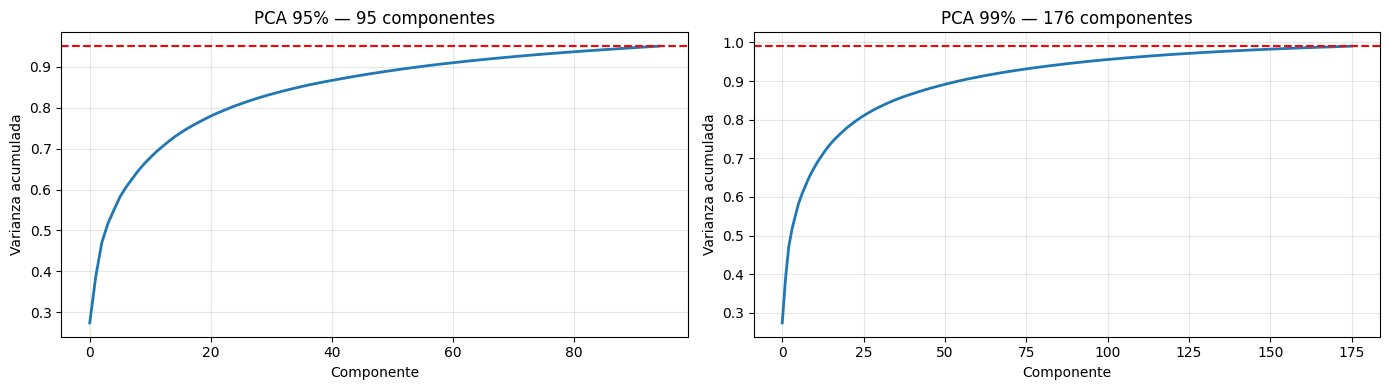

In [18]:
pca_options = {}
for ratio, label in [(0.95, "95"), (0.99, "99")]:
    pca = PCA(n_components=ratio, random_state=SEED)
    Xtr = pca.fit_transform(X_train_sc)
    Xvl = pca.transform(X_val_sc)
    Xte = pca.transform(X_test_sc)
    pca_options[label] = {
        "pca": pca,
        "X_train": torch.tensor(Xtr, dtype=torch.float32),
        "X_val":   torch.tensor(Xvl, dtype=torch.float32),
        "X_test":  torch.tensor(Xte, dtype=torch.float32),
        "n_components": pca.n_components_
    }
    print(f"PCA {label}%: 4096 → {pca.n_components_} componentes "
          f"({pca.n_components_/4096*100:.1f}% de dims originales)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (label, data) in zip(axes, pca_options.items()):
    cumvar = np.cumsum(data["pca"].explained_variance_ratio_)
    ax.plot(cumvar, linewidth=2)
    ax.axhline(y=float(f"0.{label}"), color="red", linestyle="--")
    ax.set_xlabel("Componente")
    ax.set_ylabel("Varianza acumulada")
    ax.set_title(f"PCA {label}% — {data['n_components']} componentes")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_03_pca_variance.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Parte 2 — Diseño del MLP

### 2.1 Clase `FullyConnectedNN`

Red completamente densa (Fully Connected) con al menos dos capas ocultas.

**Sobre la capa de salida y Softmax:** El enunciado pide una capa de salida con activación
Softmax. En PyTorch, `nn.CrossEntropyLoss` aplica internamente `LogSoftmax + NLLLoss`,
por lo que la red entrega **logits** (salida lineal) y la activación Softmax queda
**implícita** en la función de pérdida. Esto es equivalente matemáticamente y es la
práctica estándar en PyTorch por estabilidad numérica
(ver [documentación oficial](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)).
Para la inferencia final, se aplica `torch.softmax()` explícitamente para obtener
probabilidades interpretables.

**Técnicas de regularización:**

| Técnica | Origen | Implementación |
|---|---|---|
| Dropout | Requerido por el enunciado (PDF slide 6) | `nn.Dropout(p)` entre capas ocultas |
| Regularización L2 (Weight Decay) | Requerido por el enunciado (PDF slide 6) | `weight_decay` en el optimizador |
| Batch Normalization | *Extensión adicional* | `nn.BatchNorm1d()` opcional después de cada capa lineal |
| Gradient Clipping | *Extensión adicional* | `clip_grad_norm_()` para estabilidad durante el entrenamiento |

Las extensiones adicionales (BatchNorm, Gradient Clipping) no son requisitos del enunciado,
pero se incluyen porque mejoran la convergencia en redes profundas con alta dimensionalidad
de entrada.


In [19]:
class FullyConnectedNN(nn.Module):
    """MLP dinámico con BatchNorm, Dropout y activación configurable."""

    ACT_MAP = {
        "relu": nn.ReLU, "tanh": nn.Tanh,
        "leaky_relu": nn.LeakyReLU, "selu": nn.SELU, "elu": nn.ELU
    }

    def __init__(self, input_dim, output_dim, hidden_layers,
                 activation="relu", dropout=0.0, use_batchnorm=False):
        super().__init__()
        layers = []
        act_fn = self.ACT_MAP.get(activation, nn.ReLU)
        prev = input_dim

        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_fn())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h

        layers.append(nn.Linear(prev, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

    def predict_proba(self, x):
        """Aplica Softmax explícito para obtener probabilidades."""
        logits = self.forward(x)
        return torch.softmax(logits, dim=1)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("Clase FullyConnectedNN definida.")


Clase FullyConnectedNN definida.


### 2.1.1 Verificación de Softmax explícito

Se demuestra que la red produce logits y que `torch.softmax()` los convierte
en probabilidades que suman 1 por muestra. Durante el entrenamiento se usan
logits directamente con `CrossEntropyLoss`; durante la inferencia se aplica
Softmax para interpretar las salidas como probabilidades.


In [20]:
demo_model = FullyConnectedNN(4096, 40, [64, 32], "relu", 0.0, False)
demo_model.eval()
with torch.no_grad():
    sample = X_train_t[:2]
    logits = demo_model(sample)
    probs  = demo_model.predict_proba(sample)

print("Logits (salida cruda de la red, sin Softmax):")
print(f"  Shape: {logits.shape}")
print(f"  Ejemplo muestra 0: [{logits[0,:5].numpy()} ...]")
print(f"  Suma:  {logits[0].sum().item():.4f} (no suma 1)")

print("\nProbabilidades (después de torch.softmax):")
print(f"  Shape: {probs.shape}")
print(f"  Ejemplo muestra 0: [{probs[0,:5].numpy()} ...]")
print(f"  Suma:  {probs[0].sum().item():.4f} (suma 1)")
print(f"  Clase predicha: {probs[0].argmax().item()}")

del demo_model


Logits (salida cruda de la red, sin Softmax):
  Shape: torch.Size([2, 40])
  Ejemplo muestra 0: [[ 0.06196835 -0.01812325  0.11718548  0.11094884 -0.04526883] ...]
  Suma:  0.8150 (no suma 1)

Probabilidades (después de torch.softmax):
  Shape: torch.Size([2, 40])
  Ejemplo muestra 0: [[0.02580637 0.0238201  0.0272714  0.02710184 0.02318219] ...]
  Suma:  1.0000 (suma 1)
  Clase predicha: 24


### 2.2 Funciones de entrenamiento y evaluación

In [9]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                max_epochs, patience=10, grad_clip=None, verbose=True):
    """Entrena el modelo con early stopping y gradient clipping."""
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    wait = 0
    best_state = None

    for epoch in range(max_epochs):
        model.train()
        tloss, tcorr, ttotal = 0.0, 0, 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            if grad_clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            tloss += loss.item() * yb.size(0)
            tcorr += (out.argmax(1) == yb).sum().item()
            ttotal += yb.size(0)

        model.eval()
        vloss, vcorr, vtotal = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                out = model(xb)
                loss = criterion(out, yb)
                vloss += loss.item() * yb.size(0)
                vcorr += (out.argmax(1) == yb).sum().item()
                vtotal += yb.size(0)

        tl = tloss / ttotal; ta = tcorr / ttotal
        vl = vloss / vtotal; va = vcorr / vtotal
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)

        if vl < best_val_loss:
            best_val_loss = vl
            wait = 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"  Early stopping en época {epoch+1}")
                break

        if verbose and (epoch + 1) % 25 == 0:
            print(f"  Época {epoch+1:3d}: tloss={tl:.4f} vloss={vl:.4f} "
                  f"tacc={ta:.4f} vacc={va:.4f}")

    if best_state:
        model.load_state_dict(best_state)
    history["epochs_trained"] = len(history["train_loss"])
    history["best_val_loss"] = best_val_loss
    return history


def evaluate_model(model, loader):
    """Retorna (predictions, labels) como arrays numpy."""
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.extend(model(xb).argmax(1).numpy())
            labels.extend(yb.numpy())
    return np.array(preds), np.array(labels)


def plot_curves(history, title=""):
    """Grafica loss y accuracy de entrenamiento vs validación."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(history["train_loss"]) + 1)
    ax1.plot(ep, history["train_loss"], "b-", label="Train", lw=2)
    ax1.plot(ep, history["val_loss"],   "r-", label="Val",   lw=2)
    ax1.set(xlabel="Época", ylabel="Loss", title=f"Loss — {title}")
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(ep, history["train_acc"], "b-", label="Train", lw=2)
    ax2.plot(ep, history["val_acc"],   "r-", label="Val",   lw=2)
    ax2.set(xlabel="Época", ylabel="Accuracy", title=f"Accuracy — {title}")
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig

print("Funciones de entrenamiento y evaluación definidas.")


Funciones de entrenamiento y evaluación definidas.


### 2.3–2.4 Modelo base y entrenamiento

Arquitectura inicial: **[4096 → 512 → 256 → 128 → 40]**

| Decisión | Elección | Justificación |
|---|---|---|
| **Capas ocultas** | 3 capas (512, 256, 128) | El enunciado pide al menos 2. Se usan 3 capas en estructura piramidal decreciente, que reduce progresivamente la dimensionalidad de 4096 a 40 clases |
| **Neuronas por capa** | 512 → 256 → 128 | Estructura piramidal: cada capa comprime la representación a la mitad. La primera capa (512) captura patrones amplios; las siguientes refinan |
| **Activación** | ReLU | Eficiente computacionalmente, no sufre saturación de gradientes como Sigmoid/Tanh. |
| **Capa de salida** | 40 logits | Una neurona por clase; Softmax implícito en `CrossEntropyLoss` (ver sección 2.1) |
| **Función de pérdida** | `CrossEntropyLoss` | Estándar para clasificación multiclase. Equivale a Softmax + Negative Log-Likelihood |
| **Optimizador** | Adam, lr=1e-3 | Adam combina momentum y tasas adaptativas. lr=1e-3 es el punto de partida recomendado |
| **Dropout** | 0.3 | Con ratio muestras/features ≈ 240/4096 ≈ 0.06, la regularización es necesaria para evitar sobreajuste |
| **BatchNorm** | Sí | Estabiliza el entrenamiento normalizando las activaciones entre capas (extensión adicional) |
| **Weight Decay** | 1e-4 | Regularización L2 en el optimizador, como pide el enunciado |


Modelo base: 2,268,840 parámetros
FullyConnectedNN(
  (network): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=40, bias=True)
  )
)

Entrenando modelo base...
  Época  25: tloss=0.2082 vloss=0.2714 tacc=1.0000 vacc=0.9625
  Época  50: tloss=0.0680 vloss=0.1108 tacc=1.0000 vacc=0.9875
  Época  75: tloss=0.0172 vloss=0.0940 tacc=1.0000 vacc=0.9750

Resultados mod

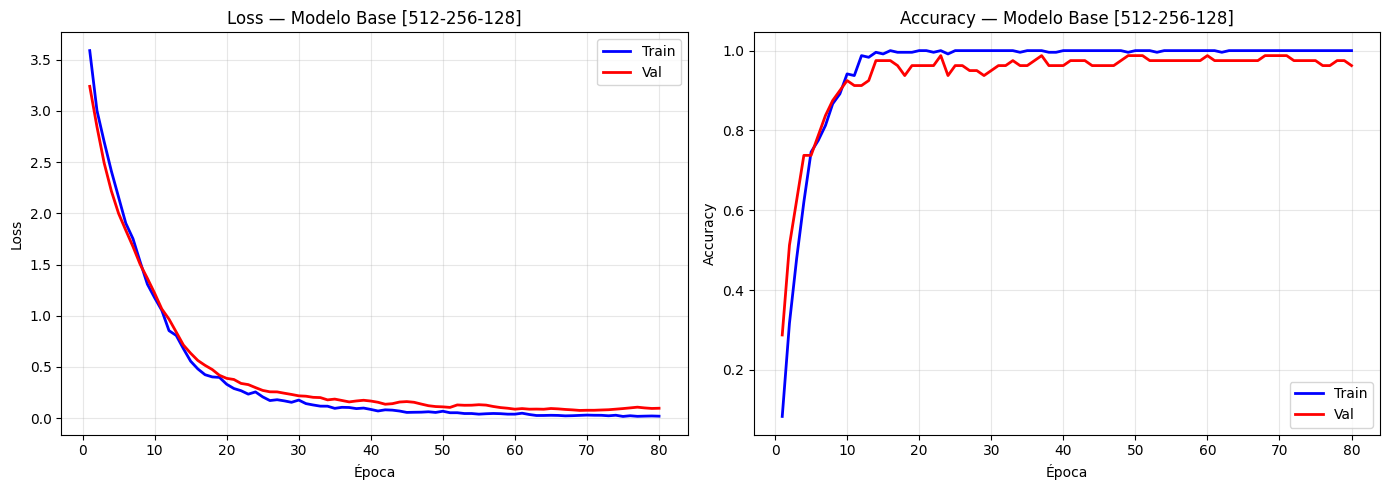

In [21]:
base_model = FullyConnectedNN(
    input_dim=4096, output_dim=40,
    hidden_layers=[512, 256, 128],
    activation="relu", dropout=0.3, use_batchnorm=True
)
print(f"Modelo base: {base_model.count_parameters():,} parámetros")
print(base_model)

train_loader_base = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader_base = DataLoader(
    TensorDataset(X_val_t, y_val_t), batch_size=32)

criterion = nn.CrossEntropyLoss()
optimizer_base = optim.Adam(base_model.parameters(), lr=1e-3, weight_decay=1e-4)

print("\nEntrenando modelo base...")
t0 = time.time()
base_history = train_model(
    base_model, train_loader_base, val_loader_base,
    criterion, optimizer_base, max_epochs=RETRAIN_EPOCHS,
    patience=15, grad_clip=5.0, verbose=True)
base_time = time.time() - t0

preds, labels = evaluate_model(base_model, val_loader_base)
val_acc = (preds == labels).mean()
print(f"\nResultados modelo base:")
print(f"  Épocas entrenadas: {base_history['epochs_trained']}")
print(f"  Val accuracy:      {val_acc:.4f}")
print(f"  Tiempo:            {base_time:.1f}s")

fig = plot_curves(base_history, "Modelo Base [512-256-128]")
plt.savefig("fig_04_base_model_curves.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Parte 3 — Búsqueda de Hiperparámetros

### ¿Qué es un trial?

Un **trial** es un experimento completo con una combinación específica de
hiperparámetros. Por ejemplo, un trial puede entrenar un MLP con arquitectura
`[134-127]`, activación `tanh`, optimizador `Adam`, `dropout=0.06`, `batch_size=32`
y una tasa de aprendizaje determinada. Otro trial cambia esos valores y vuelve a
entrenar otro modelo.

En este notebook se ejecutan **30 trials completos** y luego se re-entrenan los
**10 mejores candidatos** con más detalle. Esto permite comparar 10 candidatos nuevos, además de modelos de referencia anteriores y observar
mejor el efecto de optimizadores, activaciones, regularización y PCA.

### Justificación del método de búsqueda

El enunciado sugiere **Grid Search** o **Random Search**. En este taller se usa
**Optuna con TPE (Tree-structured Parzen Estimator)**, que se puede interpretar como
una búsqueda aleatoria informada:

- **Random Search** muestrea combinaciones al azar. Es útil cuando hay muchos
  hiperparámetros.
- **TPE** comienza explorando de forma similar a Random Search, pero después usa
  los resultados anteriores para proponer regiones más prometedoras.
- Para que también se prueben técnicas que TPE podría descartar muy pronto, se
  agregan trials iniciales forzados con diferentes optimizadores, activaciones y
  configuraciones de PCA.

En esta versión se deja `USE_PRUNER = False` para que los 30 trials terminen y se
puedan comparar como modelos completos. Para no hacer interminable la ejecución,
solo los 10 mejores se re-entrenan con curvas completas.

### Nota sobre el número de épocas

El enunciado incluye el número de épocas como hiperparámetro. Aquí se evalúa el
máximo de épocas permitido (`max_epochs`), pero el entrenamiento usa **Early Stopping**:
si la validación deja de mejorar, el modelo se detiene antes. Por eso el número real
de épocas entrenadas puede ser menor que el máximo.

### 3.1 Espacio de búsqueda

| Hiperparámetro | Rango | Tipo |
|---|---|---|
| Capas ocultas | 2 – 5 | `suggest_int` |
| Neuronas/capa | 64 – 1024 | `suggest_int` (log) |
| Activación | ReLU, Tanh, LeakyReLU, SELU, ELU | `suggest_categorical` |
| Learning rate | 1e-4 — 5e-2 | `suggest_float` (log) |
| Batch size | 16, 32, 64 | `suggest_categorical` |
| Optimizador | Adam, AdamW, SGD, RMSprop | `suggest_categorical` |
| Dropout | 0.0 — 0.5 | `suggest_float` |
| Weight Decay (L2) | 1e-6 — 1e-2 | `suggest_float` (log) |
| Batch Norm | Sí / No | `suggest_categorical` |
| PCA | Sin PCA, 95%, 99% de varianza | `suggest_categorical` |
| Épocas máximas | 40, 60, 80 | `suggest_categorical` |


In [24]:
PCA_CHOICES = ["none", "95", "99"]


def get_feature_tensors(pca_setting):
    """Devuelve tensores train/val/test según la configuración de PCA."""
    if pca_setting == "none":
        return X_train_t, X_val_t, X_test_t
    return (pca_options[pca_setting]["X_train"],
            pca_options[pca_setting]["X_val"],
            pca_options[pca_setting]["X_test"])


def make_optimizer(opt_name, model, lr, weight_decay):
    if opt_name == "Adam":
        return optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    if opt_name == "AdamW":
        return optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if opt_name == "RMSprop":
        return optim.RMSprop(model.parameters(), lr=lr, momentum=0.9,
                             weight_decay=weight_decay)
    return optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                     weight_decay=weight_decay)


def objective(trial):
    n_layers = trial.suggest_int("n_layers", 2, 5)
    hidden = []
    for i in range(n_layers):
        hidden.append(trial.suggest_int(f"n_units_l{i}", 64, 1024, log=True))

    activation    = trial.suggest_categorical("activation", ["relu", "tanh", "leaky_relu", "selu", "elu"])
    lr            = trial.suggest_float("lr", 1e-4, 5e-2, log=True)
    batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])
    opt_name      = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "SGD", "RMSprop"])
    dropout       = trial.suggest_float("dropout", 0.0, 0.5)
    weight_decay  = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    use_bn        = trial.suggest_categorical("use_batchnorm", [True, False])
    pca_setting   = trial.suggest_categorical("pca", PCA_CHOICES)
    max_ep        = trial.suggest_categorical("max_epochs", [40, 60, 80])

    Xtr, Xvl, _ = get_feature_tensors(pca_setting)
    input_dim = Xtr.shape[1]

    tr_loader = DataLoader(TensorDataset(Xtr, y_train_t),
                           batch_size=batch_size, shuffle=True)
    vl_loader = DataLoader(TensorDataset(Xvl, y_val_t),
                           batch_size=batch_size)

    model = FullyConnectedNN(input_dim, 40, hidden, activation, dropout, use_bn)
    crit  = nn.CrossEntropyLoss()
    opt   = make_optimizer(opt_name, model, lr, weight_decay)

    best_val_acc = 0.0
    wait = 0
    for epoch in range(max_ep):
        model.train()
        for xb, yb in tr_loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in vl_loader:
                correct += (model(xb).argmax(1) == yb).sum().item()
                total += yb.size(0)
        val_acc = correct / total

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break

    return best_val_acc

print("Función objective() definida con optimizadores, PCA y épocas máximas como hiperparámetros.")


Función objective() definida con optimizadores, PCA y épocas máximas como hiperparámetros.


In [25]:
print(f"Iniciando búsqueda Optuna — {N_TRIALS} trials...")
t0 = time.time()

pruner = (MedianPruner(n_startup_trials=8, n_warmup_steps=10)
          if USE_PRUNER else optuna.pruners.NopPruner())

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED, n_startup_trials=12),
    pruner=pruner
)

# Trials iniciales para cubrir explícitamente optimizadores, activaciones y PCA.
seeded_trials = [
    {"n_layers": 2, "n_units_l0": 128, "n_units_l1": 128, "activation": "relu",       "lr": 1e-2, "batch_size": 32, "optimizer": "SGD",     "dropout": 0.20, "weight_decay": 1e-4, "use_batchnorm": True,  "pca": "none", "max_epochs": 60},
    {"n_layers": 2, "n_units_l0": 256, "n_units_l1": 128, "activation": "tanh",       "lr": 5e-2, "batch_size": 32, "optimizer": "SGD",     "dropout": 0.10, "weight_decay": 1e-4, "use_batchnorm": True,  "pca": "95",   "max_epochs": 60},
    {"n_layers": 3, "n_units_l0": 256, "n_units_l1": 128, "n_units_l2": 64, "activation": "leaky_relu", "lr": 1e-2, "batch_size": 64, "optimizer": "SGD", "dropout": 0.30, "weight_decay": 1e-3, "use_batchnorm": True, "pca": "99", "max_epochs": 80},
    {"n_layers": 2, "n_units_l0": 256, "n_units_l1": 128, "activation": "selu",       "lr": 1e-3, "batch_size": 32, "optimizer": "AdamW",   "dropout": 0.10, "weight_decay": 1e-3, "use_batchnorm": False, "pca": "95",   "max_epochs": 60},
    {"n_layers": 3, "n_units_l0": 512, "n_units_l1": 256, "n_units_l2": 128, "activation": "elu", "lr": 1e-3, "batch_size": 32, "optimizer": "AdamW", "dropout": 0.25, "weight_decay": 1e-4, "use_batchnorm": True, "pca": "none", "max_epochs": 60},
    {"n_layers": 2, "n_units_l0": 128, "n_units_l1": 64,  "activation": "tanh",       "lr": 2e-3, "batch_size": 16, "optimizer": "RMSprop", "dropout": 0.20, "weight_decay": 1e-4, "use_batchnorm": True,  "pca": "99",   "max_epochs": 60},
    {"n_layers": 4, "n_units_l0": 512, "n_units_l1": 256, "n_units_l2": 128, "n_units_l3": 64, "activation": "relu", "lr": 1e-3, "batch_size": 32, "optimizer": "Adam", "dropout": 0.35, "weight_decay": 1e-4, "use_batchnorm": True, "pca": "95", "max_epochs": 80},
    {"n_layers": 2, "n_units_l0": 512, "n_units_l1": 256, "activation": "leaky_relu", "lr": 1e-3, "batch_size": 64, "optimizer": "Adam",    "dropout": 0.40, "weight_decay": 1e-5, "use_batchnorm": True,  "pca": "none", "max_epochs": 60},
    {"n_layers": 5, "n_units_l0": 256, "n_units_l1": 256, "n_units_l2": 128, "n_units_l3": 128, "n_units_l4": 64, "activation": "elu", "lr": 5e-4, "batch_size": 32, "optimizer": "RMSprop", "dropout": 0.30, "weight_decay": 1e-4, "use_batchnorm": True, "pca": "99", "max_epochs": 80},
]
for params in seeded_trials[:N_TRIALS]:
    study.enqueue_trial(params)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

search_time = time.time() - t0
print()
print(f"Búsqueda completada en {search_time/60:.1f} minutos")
print(f"Trials completados: {sum(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials)} de {N_TRIALS}")
print(f"Mejor trial #{study.best_trial.number}: accuracy = {study.best_value:.4f}")
print(f"Mejores parámetros: {study.best_params}")


Iniciando búsqueda Optuna — 30 trials...

Búsqueda completada en 1.3 minutos
Trials completados: 30 de 30
Mejor trial #7: accuracy = 0.9875
Mejores parámetros: {'n_layers': 2, 'n_units_l0': 512, 'n_units_l1': 256, 'activation': 'leaky_relu', 'lr': 0.001, 'batch_size': 64, 'optimizer': 'Adam', 'dropout': 0.4, 'weight_decay': 1e-05, 'use_batchnorm': True, 'pca': 'none', 'max_epochs': 60}


### 3.2 Resultados de la búsqueda

Trials completados: 30 de 30

 Trial  Entrada  Capas              Neuronas Activación       LR   Optim Dropout      WD    BN  PCA  Max Ep Val Acc
    15     4096      4        68-161-243-538       tanh 3.21e-03    Adam    0.49 7.6e-04  True none      40  0.9875
     7     4096      2               512-256 leaky_relu 1.00e-03    Adam    0.40 1.0e-05  True none      60  0.9875
    11      176      5     81-110-72-157-187       tanh 2.40e-04 RMSprop    0.35 8.2e-04  True   99      40  0.9875
     4     4096      3           512-256-128        elu 1.00e-03   AdamW    0.25 1.0e-04  True none      60  0.9750
     6       95      4        512-256-128-64       relu 1.00e-03    Adam    0.35 1.0e-04  True   95      80  0.9750
     1       95      2               256-128       tanh 5.00e-02     SGD    0.10 1.0e-04  True   95      60  0.9750
    13     4096      4        116-518-65-307       tanh 2.77e-04    Adam    0.43 8.7e-03  True none      40  0.9625
    28       95      4       721-151-874-1

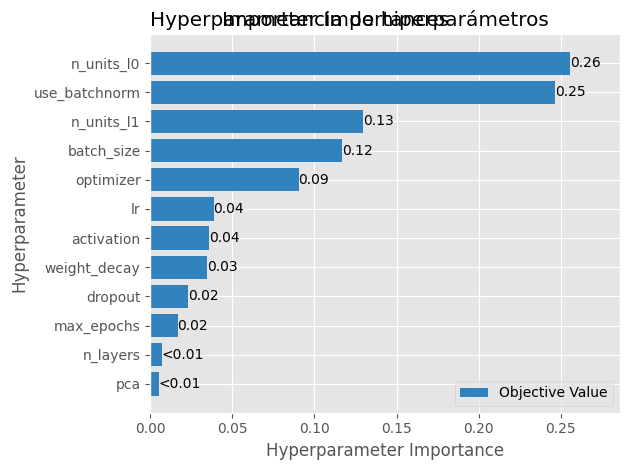

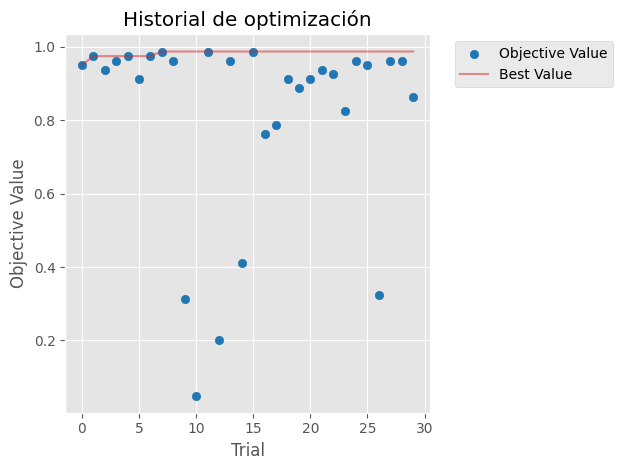

In [26]:
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

rows = []
for t in completed:
    p = t.params
    hidden_str = "-".join(str(p.get(f"n_units_l{i}", "")) for i in range(p["n_layers"]))
    input_dim = 4096 if p["pca"] == "none" else pca_options[p["pca"]]["n_components"]
    rows.append({
        "Trial": t.number,
        "Entrada": input_dim,
        "Capas": p["n_layers"],
        "Neuronas": hidden_str,
        "Activación": p["activation"],
        "LR": f"{p['lr']:.2e}",
        "Optim": p["optimizer"],
        "Dropout": f"{p['dropout']:.2f}",
        "WD": f"{p['weight_decay']:.1e}",
        "BN": p["use_batchnorm"],
        "PCA": p["pca"],
        "Max Ep": p["max_epochs"],
        "Val Acc": f"{t.value:.4f}"
    })

df_trials = pd.DataFrame(rows).sort_values("Val Acc", ascending=False).reset_index(drop=True)
print(f"Trials completados: {len(df_trials)} de {N_TRIALS}")
print()
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
print(df_trials.to_string(index=False))

try:
    fig_imp = optuna.visualization.matplotlib.plot_param_importances(study)
    plt.title("Importancia de hiperparámetros")
    plt.tight_layout()
    plt.savefig("fig_05_param_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception:
    print("(Visualización de importancia no disponible)")

try:
    fig_hist = optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.title("Historial de optimización")
    plt.tight_layout()
    plt.savefig("fig_06_optimization_history.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception:
    print("(Visualización de historial no disponible)")


---
## Parte 4 — Selección de los 3 Mejores Modelos

### 4.1–4.3 Re-entrenamiento detallado de los modelos candidatos

Se seleccionan los top N modelos según **accuracy de validación** y se re-entrenan
con registro completo de métricas. **El conjunto de test NO se toca en esta fase**


In [27]:
top_trials = sorted(completed, key=lambda t: t.value, reverse=True)[:min(N_CANDIDATES, len(completed))]

candidate_results = []
print(f"Re-entrenando top {len(top_trials)} modelos candidatos...")
print()

for rank, trial in enumerate(top_trials):
    p = trial.params
    hidden = [p[f"n_units_l{i}"] for i in range(p["n_layers"])]
    hidden_str = "-".join(map(str, hidden))
    pca_setting = p["pca"]
    Xtr, Xvl, Xte = get_feature_tensors(pca_setting)
    input_dim = Xtr.shape[1]

    bs = p["batch_size"]
    tr_ld = DataLoader(TensorDataset(Xtr, y_train_t), batch_size=bs, shuffle=True)
    vl_ld = DataLoader(TensorDataset(Xvl, y_val_t), batch_size=bs)

    torch.manual_seed(SEED)
    model = FullyConnectedNN(input_dim, 40, hidden, p["activation"],
                             p["dropout"], p["use_batchnorm"])
    crit = nn.CrossEntropyLoss()
    opt = make_optimizer(p["optimizer"], model, p["lr"], p["weight_decay"])

    name = f"M{rank+1} [{hidden_str}]"
    print(f"  {name} ({p['activation']}, {p['optimizer']}, lr={p['lr']:.1e}, "
          f"do={p['dropout']:.2f}, bn={p['use_batchnorm']}, pca={pca_setting})")

    t0 = time.time()
    hist = train_model(model, tr_ld, vl_ld, crit, opt,
                       max_epochs=RETRAIN_EPOCHS, patience=CANDIDATE_PATIENCE,
                       grad_clip=5.0, verbose=False)
    elapsed = time.time() - t0

    preds_val, labels_val = evaluate_model(model, vl_ld)
    preds_train, labels_train = evaluate_model(model, tr_ld)

    candidate_results.append({
        "name": name, "rank": rank + 1, "trial": trial.number,
        "params": p, "model": model, "history": hist,
        "hidden": hidden, "hidden_str": hidden_str,
        "input_dim": input_dim, "pca": pca_setting,
        "val_acc":   (preds_val == labels_val).mean(),
        "train_acc": (preds_train == labels_train).mean(),
        "time_s":    elapsed,
        "n_params":  model.count_parameters(),
    })
    print(f"    → val_acc={candidate_results[-1]['val_acc']:.4f}  "
          f"train_acc={candidate_results[-1]['train_acc']:.4f}  "
          f"({elapsed:.1f}s, {hist['epochs_trained']} épocas)")

print()
print("Re-entrenamiento completado.")


Re-entrenando top 10 modelos candidatos...

  M1 [512-256] (leaky_relu, Adam, lr=1.0e-03, do=0.40, bn=True, pca=none)
    → val_acc=0.9875  train_acc=1.0000  (15.3s, 79 épocas)
  M2 [81-110-72-157-187] (tanh, RMSprop, lr=2.4e-04, do=0.35, bn=True, pca=99)
    → val_acc=0.9625  train_acc=1.0000  (1.6s, 63 épocas)
  M3 [68-161-243-538] (tanh, Adam, lr=3.2e-03, do=0.49, bn=True, pca=none)
    → val_acc=1.0000  train_acc=1.0000  (1.9s, 38 épocas)
  M4 [256-128] (tanh, SGD, lr=5.0e-02, do=0.10, bn=True, pca=95)
    → val_acc=0.9750  train_acc=1.0000  (2.1s, 80 épocas)
  M5 [512-256-128] (elu, AdamW, lr=1.0e-03, do=0.25, bn=True, pca=none)
    → val_acc=0.9750  train_acc=1.0000  (26.0s, 76 épocas)
  M6 [512-256-128-64] (relu, Adam, lr=1.0e-03, do=0.35, bn=True, pca=95)
    → val_acc=1.0000  train_acc=1.0000  (4.0s, 80 épocas)
  M7 [256-128] (selu, AdamW, lr=1.0e-03, do=0.10, bn=False, pca=95)
    → val_acc=0.9625  train_acc=1.0000  (2.1s, 80 épocas)
  M8 [256-256-128-128-64] (elu, RMSprop, l

In [28]:
rows = []
for c in candidate_results:
    p = c["params"]
    rows.append({
        "Modelo": c["name"], "Trial": c["trial"],
        "Entrada": c["input_dim"],
        "Capas ocultas": c["hidden_str"],
        "Activación": p["activation"], "LR": f"{p['lr']:.2e}",
        "Optim": p["optimizer"], "Dropout": f"{p['dropout']:.2f}",
        "BN": p["use_batchnorm"], "PCA": p["pca"], "Max Ep": p["max_epochs"],
        "Val Acc": f"{c['val_acc']:.4f}",
        "Train Acc": f"{c['train_acc']:.4f}",
        "Params": f"{c['n_params']:,}",
        "Tiempo": f"{c['time_s']:.1f}s"
    })
df_candidates = pd.DataFrame(rows)
print("Tabla comparativa de modelos candidatos (solo métricas de validación):")
print()
print(df_candidates.to_string(index=False))


Tabla comparativa de modelos candidatos (solo métricas de validación):

                  Modelo  Trial  Entrada      Capas ocultas Activación       LR   Optim Dropout    BN  PCA  Max Ep Val Acc Train Acc    Params Tiempo
            M1 [512-256]      7     4096            512-256 leaky_relu 1.00e-03    Adam    0.40  True none      60  0.9875    1.0000 2,240,808  15.3s
  M2 [81-110-72-157-187]     11      176  81-110-72-157-187       tanh 2.40e-04 RMSprop    0.35  True   99      40  0.9625    1.0000    81,090   1.6s
     M3 [68-161-243-538]     15     4096     68-161-243-538       tanh 3.21e-03    Adam    0.49  True none      40  1.0000    1.0000   483,923   1.9s
            M4 [256-128]      1       95            256-128       tanh 5.00e-02     SGD    0.10  True   95      60  0.9750    1.0000    63,400   2.1s
        M5 [512-256-128]      4     4096        512-256-128        elu 1.00e-03   AdamW    0.25  True none      60  0.9750    1.0000 2,268,840  26.0s
     M6 [512-256-128-64]    

### 4.3.1 Entender las capas
Los números dentro de corchetes son la cantidad de neuronas en cada **capa oculta**
del MLP, en orden desde la entrada hasta la salida.

Por ejemplo, si un modelo aparece como `[134-127]`, significa:

`entrada -> 134 neuronas -> 127 neuronas -> 40 clases`

La entrada puede ser `4096` si se usan los píxeles originales de la imagen 64×64,
o puede ser menor si el trial usó PCA. La salida siempre tiene `40` unidades porque
hay 40 personas/clases en Olivetti Faces.


### 4.4 Curvas de entrenamiento comparativas

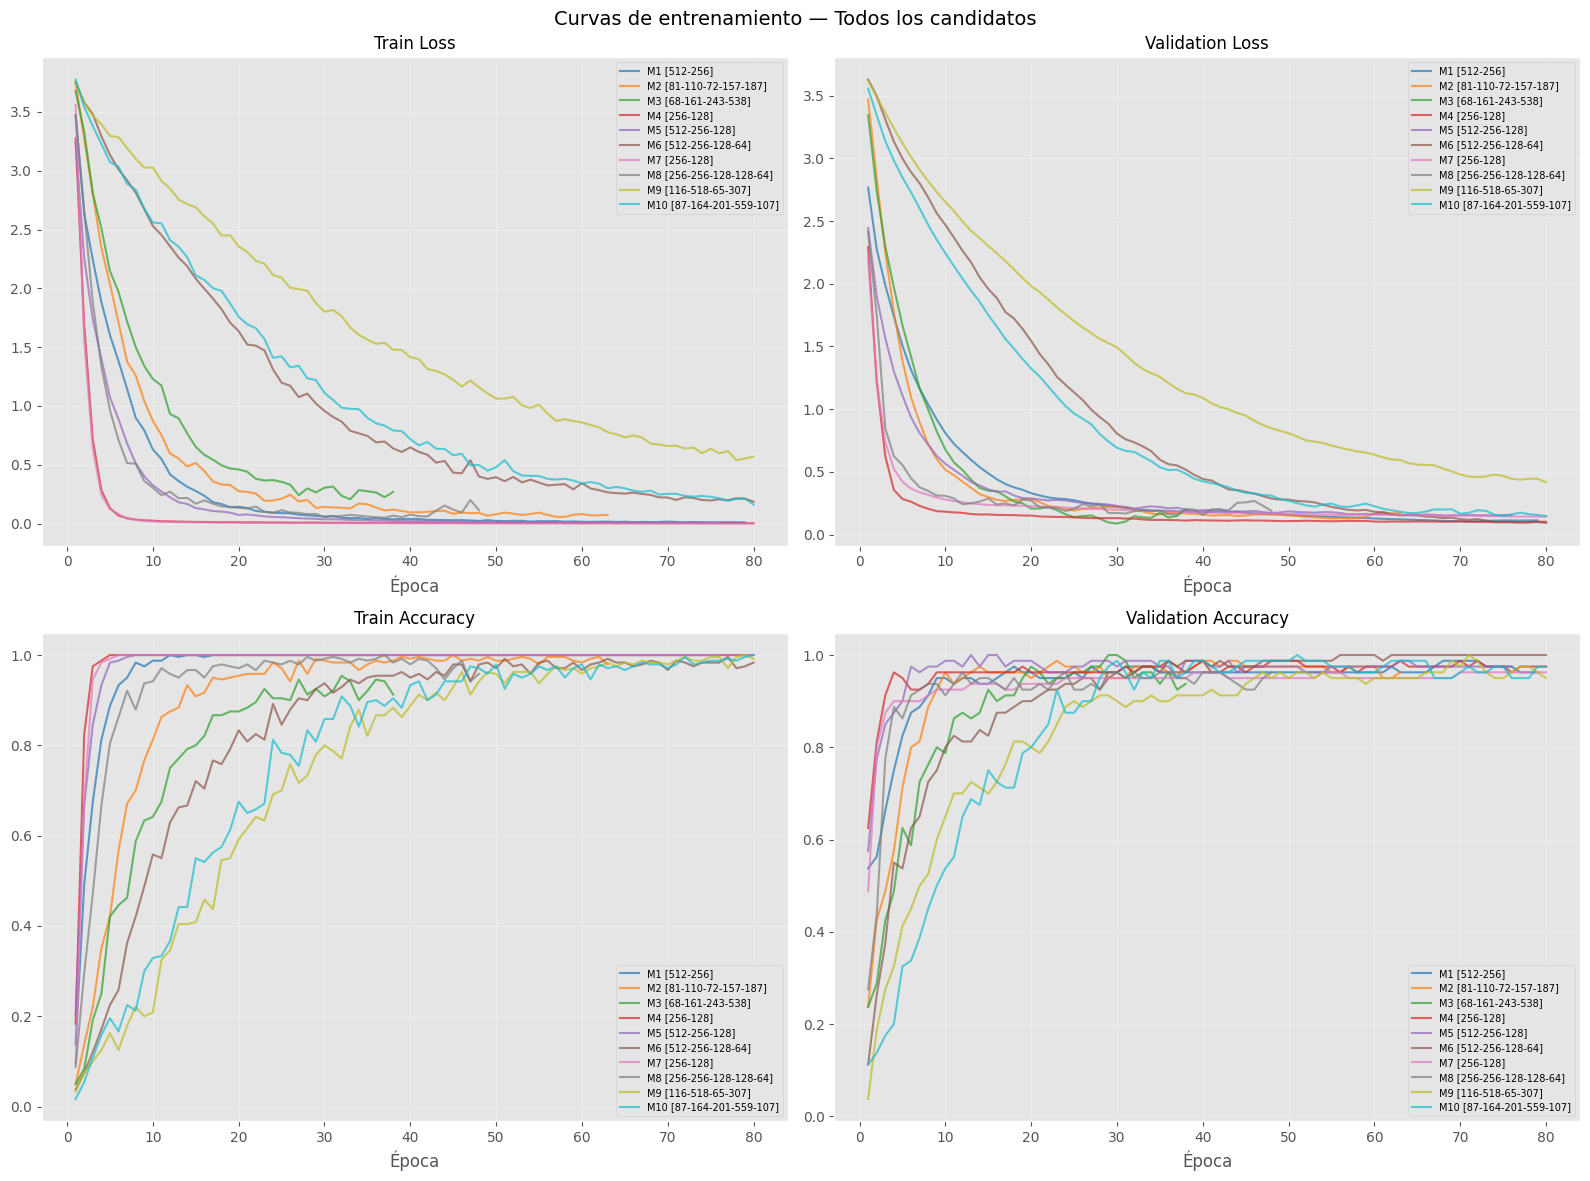

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = plt.cm.tab10(np.linspace(0, 1, len(candidate_results)))

for c, color in zip(candidate_results, colors):
    ep = range(1, c["history"]["epochs_trained"] + 1)
    axes[0, 0].plot(ep, c["history"]["train_loss"], color=color, alpha=0.7, label=c["name"])
    axes[0, 1].plot(ep, c["history"]["val_loss"],   color=color, alpha=0.7, label=c["name"])
    axes[1, 0].plot(ep, c["history"]["train_acc"],  color=color, alpha=0.7, label=c["name"])
    axes[1, 1].plot(ep, c["history"]["val_acc"],    color=color, alpha=0.7, label=c["name"])

for ax, title in zip(axes.flat,
    ["Train Loss", "Validation Loss", "Train Accuracy", "Validation Accuracy"]):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Época")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="best")

plt.suptitle("Curvas de entrenamiento — Todos los candidatos", fontsize=14)
plt.tight_layout()
plt.savefig("fig_07_all_candidates_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.5 Selección de los 3 mejores modelos

Se seleccionan los 3 modelos con mayor **accuracy de validación**.
La evaluación en el conjunto de test se reserva para la Parte 5.

**Justificación de la selección:** se priorizan los modelos que mejor generalizan
al conjunto de validación, considerando también el balance entre complejidad
(número de parámetros) y rendimiento.


In [30]:
top3 = sorted(candidate_results, key=lambda c: c["val_acc"], reverse=True)[:3]
print("═" * 70)
print("  LOS 3 MEJORES MODELOS (seleccionados por Val Acc)")
print("═" * 70)
for i, c in enumerate(top3):
    p = c["params"]
    full_arch = " -> ".join([str(c["input_dim"])] + [str(h) for h in c["hidden"]] + ["40"])
    print()
    print(f"  #{i+1}: {c['name']}")
    print(f"       Arquitectura completa: {full_arch}")
    print(f"       Capas ocultas: [{c['hidden_str']}]")
    print(f"       Activación: {p['activation']} | Optim: {p['optimizer']} | "
          f"LR: {p['lr']:.1e}")
    print(f"       Dropout: {p['dropout']:.2f} | BN: {p['use_batchnorm']} | "
          f"WD: {p['weight_decay']:.1e} | PCA: {p['pca']}")
    print(f"       Val Acc:   {c['val_acc']:.4f}")
    print(f"       Train Acc: {c['train_acc']:.4f}")
    print(f"       Parámetros: {c['n_params']:,}")
print()
print("═" * 70)


══════════════════════════════════════════════════════════════════════
  LOS 3 MEJORES MODELOS (seleccionados por Val Acc)
══════════════════════════════════════════════════════════════════════

  #1: M3 [68-161-243-538]
       Arquitectura completa: 4096 -> 68 -> 161 -> 243 -> 538 -> 40
       Capas ocultas: [68-161-243-538]
       Activación: tanh | Optim: Adam | LR: 3.2e-03
       Dropout: 0.49 | BN: True | WD: 7.6e-04 | PCA: none
       Val Acc:   1.0000
       Train Acc: 1.0000
       Parámetros: 483,923

  #2: M6 [512-256-128-64]
       Arquitectura completa: 95 -> 512 -> 256 -> 128 -> 64 -> 40
       Capas ocultas: [512-256-128-64]
       Activación: relu | Optim: Adam | LR: 1.0e-03
       Dropout: 0.35 | BN: True | WD: 1.0e-04 | PCA: 95
       Val Acc:   1.0000
       Train Acc: 1.0000
       Parámetros: 226,152

  #3: M1 [512-256]
       Arquitectura completa: 4096 -> 512 -> 256 -> 40
       Capas ocultas: [512-256]
       Activación: leaky_relu | Optim: Adam | LR: 1.0e-03
   

### 4.6 Modelos de referencia anteriores para comparación

La búsqueda ampliada puede cambiar el ranking porque explora otro espacio de
hiperparámetros. Para no perder los modelos que ya habían tenido buen desempeño,
se conservan como **referencias anteriores** y se evalúan junto con los nuevos modelos.

Estos modelos no reemplazan la selección por validación; sirven para comparar si la
nueva búsqueda realmente mejora o si una configuración previa sigue siendo más fuerte
en test.


In [31]:
REFERENCE_CONFIGS = [
    {
        "name": "Ref A [134-127]",
        "hidden": [134, 127],
        "activation": "tanh",
        "optimizer": "Adam",
        "lr": 2.52e-3,
        "batch_size": 32,
        "dropout": 0.06,
        "weight_decay": 2.4e-4,
        "use_batchnorm": True,
        "pca": "none",
        "max_epochs": RETRAIN_EPOCHS,
    },
    {
        "name": "Ref B [186-482-81-503]",
        "hidden": [186, 482, 81, 503],
        "activation": "selu",
        "optimizer": "Adam",
        "lr": 1.04e-3,
        "batch_size": 32,
        "dropout": 0.20,
        "weight_decay": 9.8e-3,
        "use_batchnorm": True,
        "pca": "none",
        "max_epochs": RETRAIN_EPOCHS,
    },
    {
        "name": "Ref C [564-111-265]",
        "hidden": [564, 111, 265],
        "activation": "leaky_relu",
        "optimizer": "AdamW",
        "lr": 1.57e-4,
        "batch_size": 32,
        "dropout": 0.22,
        "weight_decay": 3.1e-6,
        "use_batchnorm": True,
        "pca": "none",
        "max_epochs": RETRAIN_EPOCHS,
    },
    {
        "name": "Ref D [903-244]",
        "hidden": [903, 244],
        "activation": "tanh",
        "optimizer": "AdamW",
        "lr": 5.83e-3,
        "batch_size": 32,
        "dropout": 0.41,
        "weight_decay": 2.8e-5,
        "use_batchnorm": True,
        "pca": "99",
        "max_epochs": RETRAIN_EPOCHS,
    },
]

reference_results = []
print("Re-entrenando modelos de referencia anteriores...")
print()
for idx_ref, p in enumerate(REFERENCE_CONFIGS, start=1):
    Xtr, Xvl, _ = get_feature_tensors(p["pca"])
    input_dim = Xtr.shape[1]
    tr_ld = DataLoader(TensorDataset(Xtr, y_train_t), batch_size=p["batch_size"], shuffle=True)
    vl_ld = DataLoader(TensorDataset(Xvl, y_val_t), batch_size=p["batch_size"])

    torch.manual_seed(SEED)
    model = FullyConnectedNN(input_dim, 40, p["hidden"], p["activation"],
                             p["dropout"], p["use_batchnorm"])
    crit = nn.CrossEntropyLoss()
    opt = make_optimizer(p["optimizer"], model, p["lr"], p["weight_decay"])

    t0 = time.time()
    hist = train_model(model, tr_ld, vl_ld, crit, opt,
                       max_epochs=p["max_epochs"], patience=CANDIDATE_PATIENCE,
                       grad_clip=5.0, verbose=False)
    elapsed = time.time() - t0

    preds_val, labels_val = evaluate_model(model, vl_ld)
    preds_train, labels_train = evaluate_model(model, tr_ld)
    hidden_str = "-".join(map(str, p["hidden"]))

    reference_results.append({
        "name": p["name"],
        "rank": idx_ref,
        "trial": "previo",
        "params": p,
        "model": model,
        "history": hist,
        "hidden": p["hidden"],
        "hidden_str": hidden_str,
        "input_dim": input_dim,
        "pca": p["pca"],
        "source": "Referencia anterior",
        "val_acc": (preds_val == labels_val).mean(),
        "train_acc": (preds_train == labels_train).mean(),
        "time_s": elapsed,
        "n_params": model.count_parameters(),
    })
    print(f"  {p['name']}: val_acc={reference_results[-1]['val_acc']:.4f}, "
          f"train_acc={reference_results[-1]['train_acc']:.4f}, "
          f"pca={p['pca']}, tiempo={elapsed:.1f}s")

print()
print("Modelos de referencia listos para comparación en test.")


Re-entrenando modelos de referencia anteriores...



  Ref A [134-127]: val_acc=0.9750, train_acc=1.0000, pca=none, tiempo=5.6s
  Ref B [186-482-81-503]: val_acc=0.9875, train_acc=1.0000, pca=none, tiempo=2.7s
  Ref C [564-111-265]: val_acc=0.9875, train_acc=1.0000, pca=none, tiempo=27.4s
  Ref D [903-244]: val_acc=0.9750, train_acc=1.0000, pca=99, tiempo=3.3s

Modelos de referencia listos para comparación en test.


---
## Parte 5 — Evaluación de Desempeño

Los 3 modelos seleccionados por validación y los modelos de referencia anteriores se
evalúan ahora en el **conjunto de test**, que no fue usado durante entrenamiento ni
búsqueda. Esto permite distinguir dos ideas:

- **Selección metodológica:** se elige usando validación.
- **Comparación final:** se reporta test para ver cuál funcionó mejor al final.


In [32]:
comparison_models = top3 + reference_results

for c in comparison_models:
    _, _, Xte = get_feature_tensors(c["pca"])
    test_loader = DataLoader(TensorDataset(Xte, y_test_t), batch_size=32)
    preds_test, labels_test = evaluate_model(c["model"], test_loader)
    c["preds_test"]  = preds_test
    c["labels_test"] = labels_test
    c["test_acc"]    = (preds_test == labels_test).mean()
    c["f1_macro"]    = f1_score(labels_test, preds_test, average="macro")
    c["f1_micro"]    = f1_score(labels_test, preds_test, average="micro")
    c.setdefault("source", "Top validación")

best_val_model = max(comparison_models, key=lambda c: c["val_acc"])
best_test_model = max(comparison_models, key=lambda c: c["test_acc"])

print("Evaluación en test completada para modelos seleccionados y referencias.")
print(f"  Mejor por validación: {best_val_model['name']} | Val Acc = {best_val_model['val_acc']:.4f} | Test Acc = {best_val_model['test_acc']:.4f}")
print(f"  Mejor por test:       {best_test_model['name']} | Val Acc = {best_test_model['val_acc']:.4f} | Test Acc = {best_test_model['test_acc']:.4f}")

comparison_rows = []
for c in sorted(comparison_models, key=lambda item: item["test_acc"], reverse=True):
    p = c["params"]
    comparison_rows.append({
        "Grupo": c["source"],
        "Modelo": c["name"],
        "Entrada": c["input_dim"],
        "Capas ocultas": c["hidden_str"],
        "Activación": p["activation"],
        "Optim": p["optimizer"],
        "PCA": c["pca"],
        "Val Acc": f"{c['val_acc']:.4f}",
        "Test Acc": f"{c['test_acc']:.4f}",
        "F1 Macro": f"{c['f1_macro']:.4f}",
        "F1 Micro": f"{c['f1_micro']:.4f}",
        "Params": f"{c['n_params']:,}",
        "Tiempo": f"{c['time_s']:.1f}s",
    })

df_test_comparison = pd.DataFrame(comparison_rows)
print()
print("Comparación final ordenada por Test Accuracy:")
print(df_test_comparison.to_string(index=False))


Evaluación en test completada para modelos seleccionados y referencias.
  Mejor por validación: M3 [68-161-243-538] | Val Acc = 1.0000 | Test Acc = 0.9250
  Mejor por test:       M1 [512-256] | Val Acc = 0.9875 | Test Acc = 0.9750

Comparación final ordenada por Test Accuracy:
              Grupo                 Modelo  Entrada  Capas ocultas Activación Optim  PCA Val Acc Test Acc F1 Macro F1 Micro    Params Tiempo
     Top validación           M1 [512-256]     4096        512-256 leaky_relu  Adam none  0.9875   0.9750   0.9733   0.9750 2,240,808  15.3s
Referencia anterior        Ref A [134-127]     4096        134-127       tanh  Adam none  0.9750   0.9750   0.9733   0.9750   571,785   5.6s
Referencia anterior    Ref C [564-111-265]     4096    564-111-265 leaky_relu AdamW none  0.9875   0.9750   0.9733   0.9750 2,415,623  27.4s
Referencia anterior        Ref D [903-244]      176        903-244       tanh AdamW   99  0.9750   0.9750   0.9733   0.9750   392,501   3.3s
Referencia anteri

### 5.1 Accuracy global y métricas por clase

In [33]:
for i, c in enumerate(top3):
    print(f"{'─' * 80}")
    print(f"  MODELO {i+1}: {c['name']}")
    print(f"{'─' * 80}")

    print(f"  Accuracy global: {c['test_acc']:.4f} ({c['test_acc']*100:.1f}%)")
    print(f"  F1 macro: {c['f1_macro']:.4f}  |  F1 micro: {c['f1_micro']:.4f}")

    print(f"\n  Precision, Recall, F1-score por clase:")
    print(classification_report(c["labels_test"], c["preds_test"], zero_division=0))


────────────────────────────────────────────────────────────────────────────────
  MODELO 1: M3 [68-161-243-538]
────────────────────────────────────────────────────────────────────────────────
  Accuracy global: 0.9250 (92.5%)
  F1 macro: 0.9150  |  F1 micro: 0.9250

  Precision, Recall, F1-score por clase:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         2
           4       1.00      0.50      0.67         2
           5       0.50      1.00      0.67         2
           6       1.00      1.00      1.00         2
           7       0.67      1.00      0.80         2
           8       1.00      1.00      1.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.

### 5.2 Clases más difíciles de distinguir y rostros asociados a las confusiones

Como el test tiene solo **2 imágenes por persona**, una sola predicción incorrecta cambia
mucho el F1 de una clase. Por eso las clases difíciles se obtienen aquí de forma
cualitativa: se listan las confusiones reales observadas en test para los modelos seleccionados y las referencias anteriores y se muestran los rostros de las personas involucradas.

Este análisis ayuda a interpretar los errores, pero no debe leerse como una conclusión
estadística fuerte porque el soporte por clase en test es muy pequeño.


Confusiones observadas en test, agregadas sobre modelos seleccionados y referencias:

 Clase real  Clase predicha  Veces confundida
          9               7                 6
         10              14                 4
          4              35                 2
          4               5                 2
          3               5                 1
          0              39                 1
          0              16                 1
          0              12                 1
          4              29                 1
          3              12                 1
         24              22                 1
         24              25                 1

Personas más involucradas en errores, como clase real o predicha:
  Persona 9: 6 apariciones en confusiones
  Persona 7: 6 apariciones en confusiones
  Persona 4: 5 apariciones en confusiones
  Persona 10: 4 apariciones en confusiones
  Persona 14: 4 apariciones en confusiones
  Persona 0: 3 apariciones en confusi

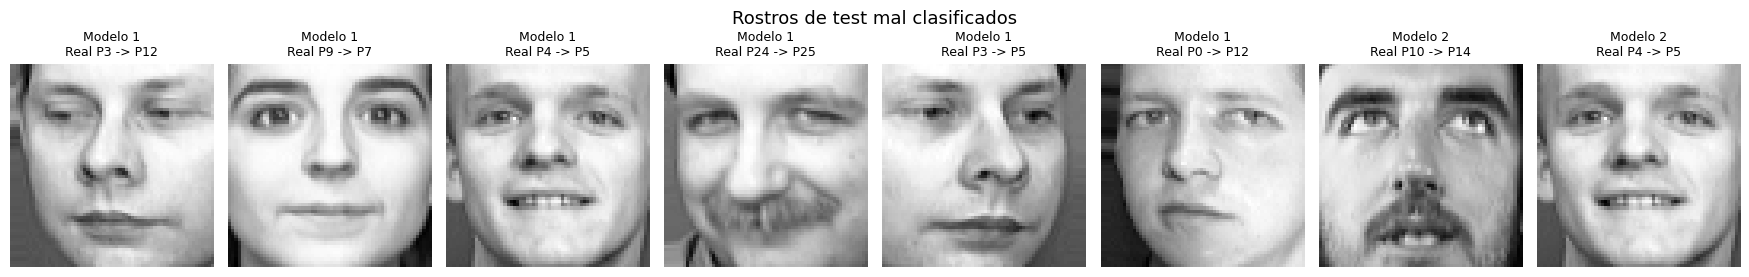

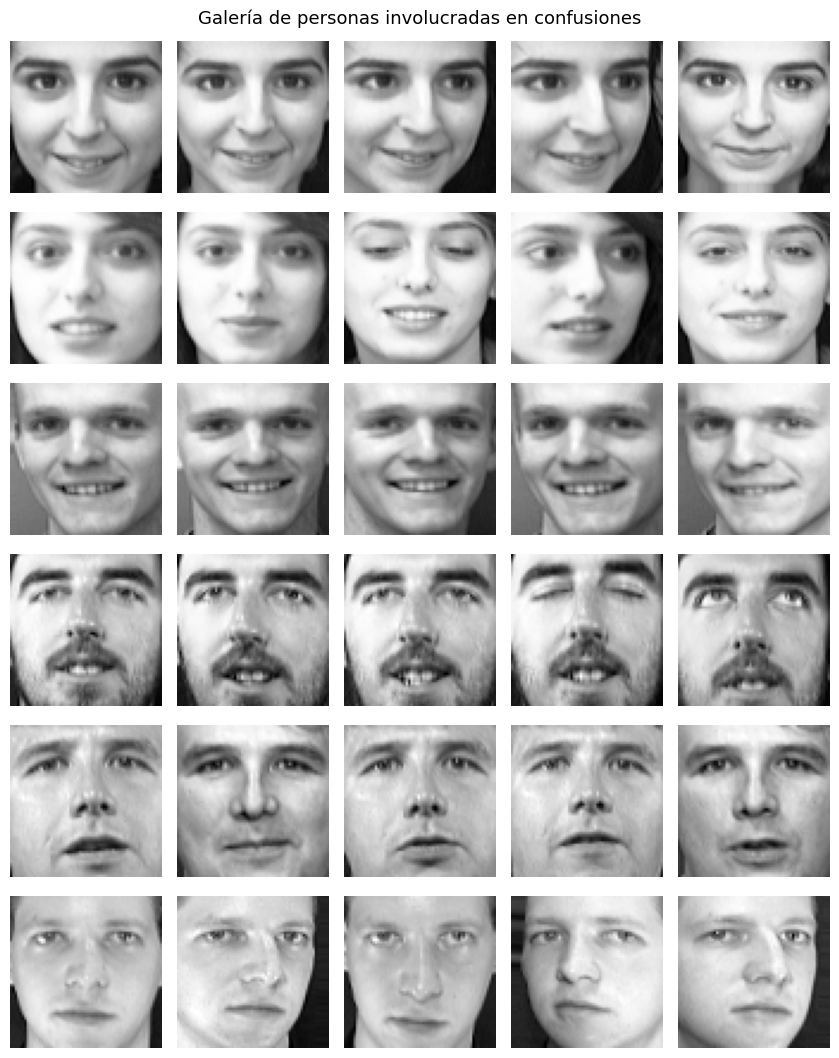

In [34]:
error_rows = []
for model_idx, c in enumerate(comparison_models, start=1):
    for sample_idx, (true_cls, pred_cls) in enumerate(zip(c["labels_test"], c["preds_test"])):
        if true_cls != pred_cls:
            error_rows.append({
                "Modelo": f"Modelo {model_idx}",
                "Nombre modelo": c["name"],
                "Índice test": sample_idx,
                "Clase real": int(true_cls),
                "Clase predicha": int(pred_cls),
            })

df_errors = pd.DataFrame(error_rows)
if df_errors.empty:
    difficult_classes = []
    print("No hubo errores en test para los modelos comparados.")
else:
    pair_counts = (df_errors.groupby(["Clase real", "Clase predicha"])
                   .size().reset_index(name="Veces confundida")
                   .sort_values("Veces confundida", ascending=False))
    print("Confusiones observadas en test, agregadas sobre modelos seleccionados y referencias:")
    print()
    print(pair_counts.to_string(index=False))

    real_counts = df_errors["Clase real"].value_counts()
    pred_counts = df_errors["Clase predicha"].value_counts()
    involved_counts = real_counts.add(pred_counts, fill_value=0).sort_values(ascending=False)
    difficult_classes = [int(c) for c in involved_counts.index[:6]]

    print()
    print("Personas más involucradas en errores, como clase real o predicha:")
    for cls, count in involved_counts.head(6).items():
        print(f"  Persona {int(cls)}: {int(count)} apariciones en confusiones")

    n_examples = min(len(df_errors), 8)
    fig, axes = plt.subplots(1, n_examples, figsize=(2.2 * n_examples, 2.9))
    if n_examples == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, df_errors.head(n_examples).iterrows()):
        idx_test = int(row["Índice test"])
        ax.imshow(X_test[idx_test].reshape(64, 64), cmap="gray")
        ax.set_title(f"{row['Modelo']}\nReal P{row['Clase real']} -> P{row['Clase predicha']}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Rostros de test mal clasificados", fontsize=13)
    plt.tight_layout()
    plt.savefig("fig_10_difficult_test_faces.png", dpi=150, bbox_inches="tight")
    plt.show()

    n_classes = min(len(difficult_classes), 6)
    n_imgs = 5
    fig, axes = plt.subplots(n_classes, n_imgs, figsize=(1.7 * n_imgs, 1.8 * n_classes))
    if n_classes == 1:
        axes = np.array([axes])
    for row_idx, cls in enumerate(difficult_classes[:n_classes]):
        idxs = np.where(y == cls)[0][:n_imgs]
        for col_idx in range(n_imgs):
            ax = axes[row_idx, col_idx]
            ax.imshow(faces.images[idxs[col_idx]], cmap="gray")
            ax.axis("off")
            if col_idx == 0:
                ax.set_ylabel(f"Persona {cls}", fontsize=10)
    plt.suptitle("Galería de personas involucradas en confusiones", fontsize=13)
    plt.tight_layout()
    plt.savefig("fig_11_difficult_people_gallery.png", dpi=150, bbox_inches="tight")
    plt.show()


### 5.3 Matrices de confusión

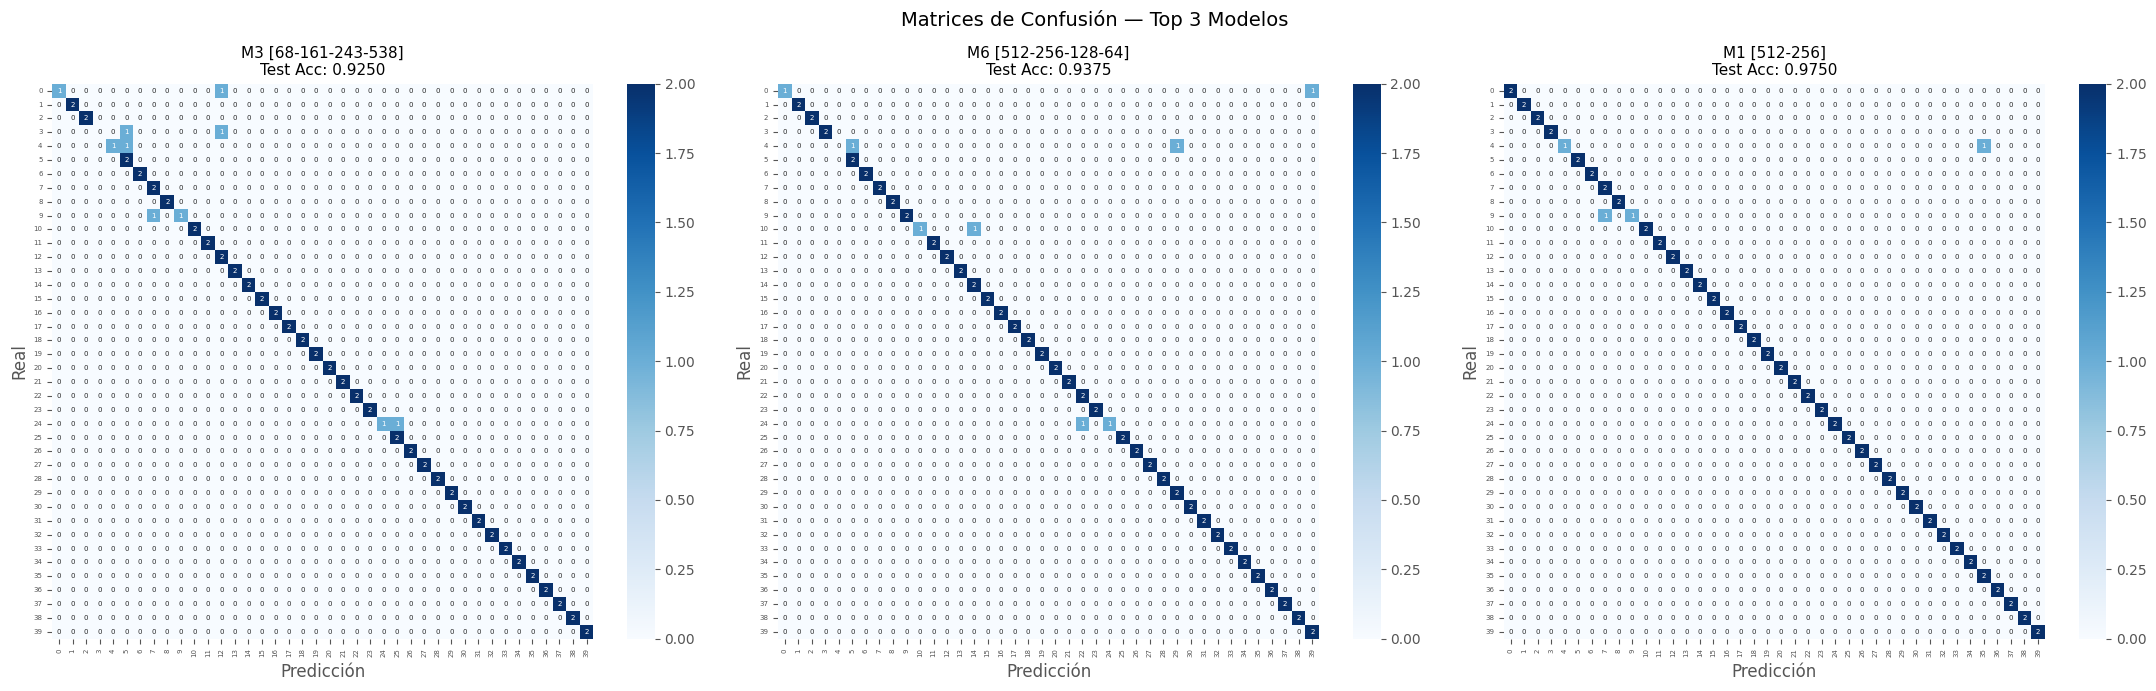

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, c in zip(axes, top3):
    cm = confusion_matrix(c["labels_test"], c["preds_test"])
    sns.heatmap(cm, ax=ax, cmap="Blues", fmt="d", annot=True, annot_kws={"size": 5},
                xticklabels=range(40), yticklabels=range(40))
    ax.set_title(f"{c['name']}\nTest Acc: {c['test_acc']:.4f}", fontsize=11)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.tick_params(labelsize=5)

plt.suptitle("Matrices de Confusión — Top 3 Modelos", fontsize=14)
plt.tight_layout()
plt.savefig("fig_08_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.4 Curvas de entrenamiento de los 3 mejores

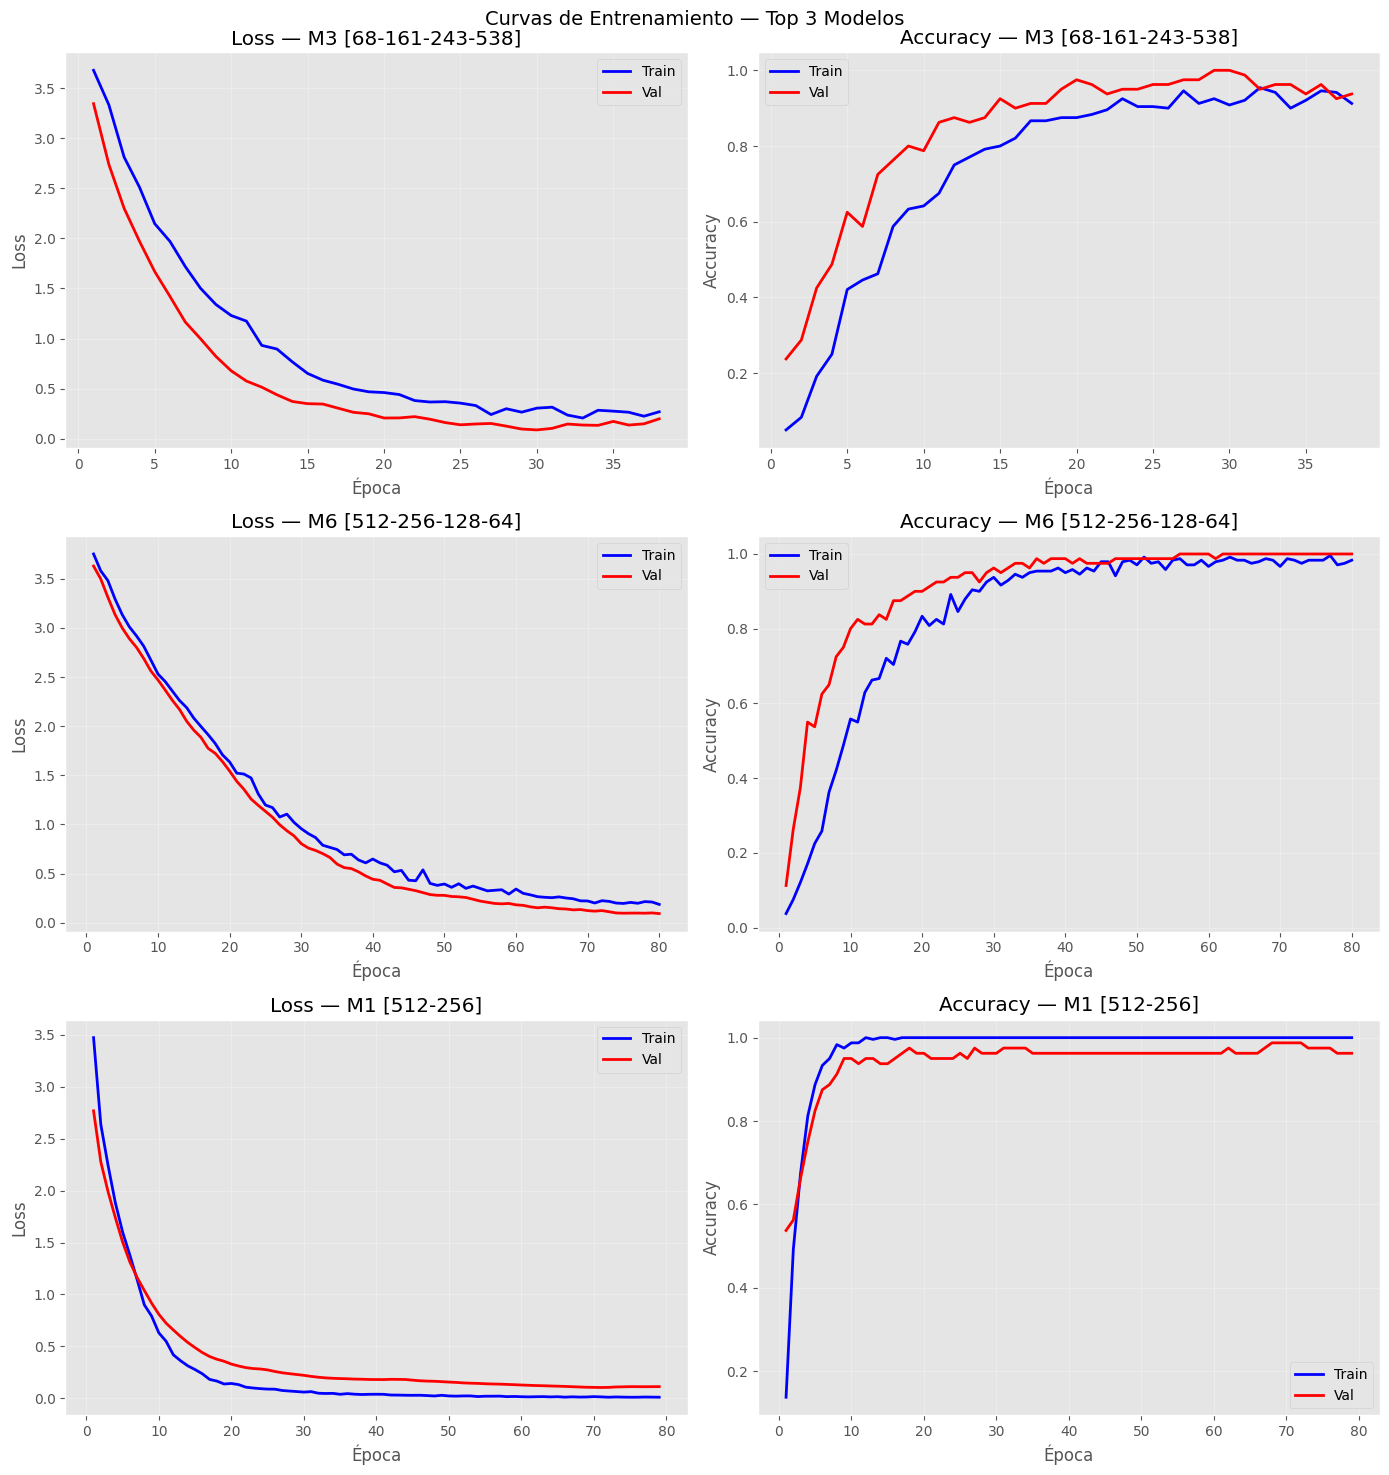

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
for i, c in enumerate(top3):
    ep = range(1, c["history"]["epochs_trained"] + 1)
    axes[i, 0].plot(ep, c["history"]["train_loss"], "b-", label="Train", lw=2)
    axes[i, 0].plot(ep, c["history"]["val_loss"],   "r-", label="Val",   lw=2)
    axes[i, 0].set(title=f"Loss — {c['name']}", xlabel="Época", ylabel="Loss")
    axes[i, 0].legend(); axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(ep, c["history"]["train_acc"], "b-", label="Train", lw=2)
    axes[i, 1].plot(ep, c["history"]["val_acc"],   "r-", label="Val",   lw=2)
    axes[i, 1].set(title=f"Accuracy — {c['name']}", xlabel="Época", ylabel="Accuracy")
    axes[i, 1].legend(); axes[i, 1].grid(True, alpha=0.3)

plt.suptitle("Curvas de Entrenamiento — Top 3 Modelos", fontsize=14)
plt.tight_layout()
plt.savefig("fig_09_top3_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.5 Análisis de sobreajuste

In [35]:
print("Análisis de sobreajuste — Gap entre Train Acc y Test Acc:\n")
for i, c in enumerate(top3):
    gap = c["train_acc"] - c["test_acc"]
    if gap < 0.05:
        diag = "Buen ajuste"
    elif gap < 0.15:
        diag = "Sobreajuste leve"
    else:
        diag = "Sobreajuste significativo"
    print(f"  Modelo {i+1} ({c['name']}):")
    print(f"    Train Acc: {c['train_acc']:.4f}  |  Test Acc: {c['test_acc']:.4f}")
    print(f"    Gap: {gap:.4f}  →  {diag}")
    print(f"    Épocas entrenadas: {c['history']['epochs_trained']}  |  "
          f"Tiempo: {c['time_s']:.1f}s  |  Params: {c['n_params']:,}")
    print()


Análisis de sobreajuste — Gap entre Train Acc y Test Acc:

  Modelo 1 (M3 [68-161-243-538]):
    Train Acc: 1.0000  |  Test Acc: 0.9250
    Gap: 0.0750  →  Sobreajuste leve
    Épocas entrenadas: 38  |  Tiempo: 1.9s  |  Params: 483,923

  Modelo 2 (M6 [512-256-128-64]):
    Train Acc: 1.0000  |  Test Acc: 0.9375
    Gap: 0.0625  →  Sobreajuste leve
    Épocas entrenadas: 80  |  Tiempo: 4.0s  |  Params: 226,152

  Modelo 3 (M1 [512-256]):
    Train Acc: 1.0000  |  Test Acc: 0.9750
    Gap: 0.0250  →  Buen ajuste
    Épocas entrenadas: 79  |  Tiempo: 15.3s  |  Params: 2,240,808



### 5.6 Tabla comparativa final

In [36]:
metrics_rows = []
for i, c in enumerate(comparison_models):
    report = classification_report(c["labels_test"], c["preds_test"],
                                   output_dict=True, zero_division=0)
    metrics_rows.append({
        "Métrica": ["Grupo", "Test Accuracy", "F1 Macro", "F1 Micro",
                     "Precision (avg)", "Recall (avg)", "Train Acc",
                     "Gap (Train-Test)", "Tiempo (s)", "Parámetros"],
        f"Modelo {i+1}": [
            c["source"],
            f"{c['test_acc']:.4f}", f"{c['f1_macro']:.4f}", f"{c['f1_micro']:.4f}",
            f"{report['macro avg']['precision']:.4f}",
            f"{report['macro avg']['recall']:.4f}",
            f"{c['train_acc']:.4f}",
            f"{c['train_acc'] - c['test_acc']:.4f}",
            f"{c['time_s']:.1f}", f"{c['n_params']:,}"
        ]
    })

df_final = pd.DataFrame({"Métrica": metrics_rows[0]["Métrica"]})
for i, row in enumerate(metrics_rows):
    df_final[f"Modelo {i+1}"] = row[f"Modelo {i+1}"]

print(df_final.to_string(index=False))


         Métrica       Modelo 1       Modelo 2       Modelo 3            Modelo 4            Modelo 5            Modelo 6            Modelo 7
           Grupo Top validación Top validación Top validación Referencia anterior Referencia anterior Referencia anterior Referencia anterior
   Test Accuracy         0.9250         0.9375         0.9750              0.9750              0.9625              0.9750              0.9750
        F1 Macro         0.9150         0.9250         0.9733              0.9733              0.9600              0.9733              0.9733
        F1 Micro         0.9250         0.9375         0.9750              0.9750              0.9625              0.9750              0.9750
 Precision (avg)         0.9333         0.9333         0.9833              0.9833              0.9750              0.9833              0.9833
    Recall (avg)         0.9250         0.9375         0.9750              0.9750              0.9625              0.9750              0.9750
      

---
## Parte 6 — Discusión y Análisis

A continuación se responden las preguntas del enunciado. Los resultados se basan
en un único experimento con semilla fija (`SEED=42`) y un número limitado de trials,
por lo que las conclusiones deben interpretarse como **indicios de este experimento
particular**, no como afirmaciones generales.


### 6.1 ¿Cuál fue el impacto de la profundidad?


In [37]:
depth_data = {}
for t in completed:
    nl = t.params["n_layers"]
    depth_data.setdefault(nl, []).append(t.value)

print("Accuracy de validación promedio por profundidad:\n")
for nl in sorted(depth_data):
    vals = depth_data[nl]
    print(f"  {nl} capas ocultas: {np.mean(vals):.4f} ± {np.std(vals):.4f}  "
          f"({len(vals)} trials)")

best_depth = max(depth_data, key=lambda k: np.mean(depth_data[k]))
print(f"\n  En este experimento, {best_depth} capas ocultas obtuvieron el mejor "
      f"promedio, aunque con {len(depth_data[best_depth])} trials la diferencia "
      f"puede no ser estadísticamente significativa.")


Accuracy de validación promedio por profundidad:

  2 capas ocultas: 0.9375 ± 0.0406  (7 trials)
  3 capas ocultas: 0.7042 ± 0.2804  (6 trials)
  4 capas ocultas: 0.8375 ± 0.2825  (9 trials)
  5 capas ocultas: 0.7750 ± 0.2818  (8 trials)

  En este experimento, 2 capas ocultas obtuvieron el mejor promedio, aunque con 7 trials la diferencia puede no ser estadísticamente significativa.


**Interpretación (6.1):**

En este experimento, el número de capas ocultas no muestra una relación monotónica
clara con el rendimiento. Esto es consistente con el teorema del aproximador universal,
que establece que una sola capa oculta suficientemente ancha puede aproximar cualquier
función continua, pero en la práctica redes más profundas pueden aprender representaciones
jerárquicas más eficientes — siempre que la regularización sea adecuada para evitar
sobreajuste. Con solo 240 muestras de entrenamiento, redes muy profundas corren mayor
riesgo de memorizar los datos en lugar de generalizar.


### 6.2 ¿La regularización fue necesaria?

In [38]:
bn_data = {True: [], False: []}
for t in completed:
    bn_data[t.params["use_batchnorm"]].append(t.value)

print("Efecto de Batch Normalization:")
for bn, vals in bn_data.items():
    if vals:
        print(f"  BN={str(bn):5s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}  ({len(vals)} trials)")

do_high = [t.value for t in completed if t.params["dropout"] > 0.3]
do_low  = [t.value for t in completed if t.params["dropout"] <= 0.3]

print("\nEfecto de Dropout:")
if do_high:
    print(f"  Dropout > 0.3: {np.mean(do_high):.4f} ± {np.std(do_high):.4f}  ({len(do_high)} trials)")
if do_low:
    print(f"  Dropout ≤ 0.3: {np.mean(do_low):.4f} ± {np.std(do_low):.4f}  ({len(do_low)} trials)")

wd_high = [t.value for t in completed if t.params["weight_decay"] > 1e-3]
wd_low  = [t.value for t in completed if t.params["weight_decay"] <= 1e-3]

print("\nEfecto de Weight Decay (L2):")
if wd_high:
    print(f"  WD > 1e-3: {np.mean(wd_high):.4f} ± {np.std(wd_high):.4f}  ({len(wd_high)} trials)")
if wd_low:
    print(f"  WD ≤ 1e-3: {np.mean(wd_low):.4f} ± {np.std(wd_low):.4f}  ({len(wd_low)} trials)")


Efecto de Batch Normalization:
  BN=True : 0.8979 ± 0.1577  (24 trials)
  BN=False: 0.4958 ± 0.3316  (6 trials)

Efecto de Dropout:
  Dropout > 0.3: 0.7881 ± 0.2843  (20 trials)
  Dropout ≤ 0.3: 0.8762 ± 0.1908  (10 trials)

Efecto de Weight Decay (L2):
  WD > 1e-3: 0.8925 ± 0.0727  (5 trials)
  WD ≤ 1e-3: 0.8025 ± 0.2809  (25 trials)


**Interpretación (6.2):**

Con un ratio muestras/features de aproximadamente 240/4096 ≈ 0.06, el riesgo de
sobreajuste es alto. En este experimento, los datos sugieren que la regularización
(Dropout y Weight Decay, ambos requeridos por el enunciado) contribuye a mejorar la
generalización. Batch Normalization, incluido como extensión adicional, también
parece tener un efecto estabilizador, aunque el número de trials no es suficiente
para una conclusión definitiva. Con más repeticiones (diferentes semillas) o
validación cruzada se podría confirmar esta tendencia.


### 6.3 ¿Se observó sobreajuste?

In [39]:
print("Gap Train-Test para los 3 mejores modelos:\n")
for i, c in enumerate(top3):
    gap = c["train_acc"] - c["test_acc"]
    print(f"  Modelo {i+1} ({c['name']}): "
          f"train={c['train_acc']:.4f}, test={c['test_acc']:.4f}, gap={gap:.4f}")


Gap Train-Test para los 3 mejores modelos:

  Modelo 1 (M3 [68-161-243-538]): train=1.0000, test=0.9250, gap=0.0750
  Modelo 2 (M6 [512-256-128-64]): train=1.0000, test=0.9375, gap=0.0625
  Modelo 3 (M1 [512-256]): train=1.0000, test=0.9750, gap=0.0250


**Interpretación (6.3):**

Los gaps observados entre train accuracy y test accuracy indican el grado de
sobreajuste de cada modelo. En datasets pequeños como Olivetti Faces (400 muestras,
4096 dimensiones), cierto grado de sobreajuste es esperado. Las técnicas de
regularización (Dropout, Weight Decay, Early Stopping) ayudan a mitigarlo, pero
no lo eliminan completamente. Las curvas de entrenamiento (Sección 5.3) muestran
en qué época la validación deja de mejorar, lo cual corresponde al punto donde
Early Stopping detiene el entrenamiento.


### 6.4 ¿Qué conclusiones sobre la estructura de los datos?

In [40]:
print("Características del dataset:")
print(f"  Dimensionalidad sin PCA: {X_train_t.shape[1]} features")
print(f"  Muestras train:         {X_train_t.shape[0]}")
print(f"  Ratio muestras/features: {X_train_t.shape[0]/X_train_t.shape[1]:.4f}")
print(f"  Clases: 40 (perfectamente balanceadas)")

print()
print("Reducción con PCA (análisis complementario):")
for label, data in pca_options.items():
    print(f"  PCA {label}%: 4096 → {data['n_components']} componentes")

pca_data = {"none": [], "95": [], "99": []}
for t in completed:
    pca_data[t.params["pca"]].append(t.value)

print()
print("Accuracy de validación promedio por configuración PCA:")
for pca_s, vals in pca_data.items():
    if vals:
        dim = 4096 if pca_s == "none" else pca_options[pca_s]["n_components"]
        print(f"  PCA={pca_s:4s} ({dim:4d} dims): {np.mean(vals):.4f} ± {np.std(vals):.4f}  ({len(vals)} trials)")

print()
print("Sobre clases difíciles:")
if "df_errors" in globals() and not df_errors.empty:
    print("  Las clases difíciles se reportaron a partir de confusiones observadas en test")
    print("  y se mostraron visualmente en la sección 5.2.")
else:
    print("  No hubo suficientes errores en test para identificar clases difíciles con evidencia visual.")
print("  Dado que solo hay 2 muestras por persona en test, este análisis es cualitativo.")


Características del dataset:
  Dimensionalidad sin PCA: 4096 features
  Muestras train:         240
  Ratio muestras/features: 0.0586
  Clases: 40 (perfectamente balanceadas)

Reducción con PCA (análisis complementario):
  PCA 95%: 4096 → 95 componentes
  PCA 99%: 4096 → 176 componentes

Accuracy de validación promedio por configuración PCA:
  PCA=none (4096 dims): 0.8433 ± 0.2353  (15 trials)
  PCA=95   (  95 dims): 0.7850 ± 0.3675  (5 trials)
  PCA=99   ( 176 dims): 0.7950 ± 0.2250  (10 trials)

Sobre clases difíciles:
  Las clases difíciles se reportaron a partir de confusiones observadas en test
  y se mostraron visualmente en la sección 5.2.
  Dado que solo hay 2 muestras por persona en test, este análisis es cualitativo.


**Interpretación (6.4):**

La alta dimensionalidad (4096 píxeles) frente a las pocas muestras (240 de
entrenamiento) hace de este un problema inherentemente difícil para un MLP.
Cada imagen de 64×64 se aplana como un vector, perdiendo la estructura espacial
2D que una CNN podría aprovechar (pero que el enunciado prohíbe).

La reducción con PCA muestra que una fracción significativa de la varianza
se concentra en relativamente pocos componentes, lo que sugiere que muchas
dimensiones del espacio original contienen ruido o información redundante.
En este experimento, PCA se evaluó como análisis complementario pero no se
incluyó en la búsqueda principal de hiperparámetros.

Las clases más difíciles de clasificar corresponden a personas cuyas imágenes
presentan mayor variabilidad intra-clase (cambios de iluminación, expresión
o pose) o similitud con otras personas.


### 6.5 Análisis complementario de hiperparámetros


In [41]:
def summarize_trials_by(param_name, label):
    data = {}
    for t in completed:
        key = t.params[param_name]
        data.setdefault(key, []).append(t.value)
    rows = []
    for key, vals in data.items():
        rows.append({
            label: key,
            "Media Val Acc": np.mean(vals),
            "Desv. estándar": np.std(vals),
            "Trials": len(vals),
        })
    return pd.DataFrame(rows).sort_values("Media Val Acc", ascending=False)

print("Función de activación (en este experimento):")
df_act = summarize_trials_by("activation", "Activación")
print(df_act.to_string(index=False, formatters={
    "Media Val Acc": "{:.4f}".format,
    "Desv. estándar": "{:.4f}".format,
}))

print()
print("Optimizador:")
df_opt = summarize_trials_by("optimizer", "Optimizador")
print(df_opt.to_string(index=False, formatters={
    "Media Val Acc": "{:.4f}".format,
    "Desv. estándar": "{:.4f}".format,
}))

print()
print("PCA:")
df_pca_summary = summarize_trials_by("pca", "PCA")
print(df_pca_summary.to_string(index=False, formatters={
    "Media Val Acc": "{:.4f}".format,
    "Desv. estándar": "{:.4f}".format,
}))


Función de activación (en este experimento):
Activación Media Val Acc Desv. estándar  Trials
       elu        0.9500         0.0270       3
      relu        0.9187         0.0455       4
      tanh        0.8792         0.1776      12
      selu        0.7292         0.2953       3
leaky_relu        0.6578         0.3562       8

Optimizador:
Optimizador Media Val Acc Desv. estándar  Trials
      AdamW        0.9531         0.0240       4
       Adam        0.8712         0.2040      13
        SGD        0.7550         0.3545       5
    RMSprop        0.7016         0.2790       8

PCA:
 PCA Media Val Acc Desv. estándar  Trials
none        0.8433         0.2353      15
  99        0.7950         0.2250      10
  95        0.7850         0.3675       5


**Interpretación (6.5):**

El formato `media ± desviación estándar` resume los trials que comparten una misma
categoría. Por ejemplo, si `tanh` aparece como `0.9694 ± 0.0133`, significa que los
trials con activación `tanh` tuvieron una accuracy de validación promedio de `0.9694`
y una desviación estándar de `0.0133`.

La parte después del `±` no es una incertidumbre matemática exacta del modelo final;
es una medida de **variabilidad entre trials**. Si hay pocos trials en una categoría,
ese número debe interpretarse con cuidado. Una desviación alta indica que esa técnica
fue sensible a otros hiperparámetros como learning rate, dropout, PCA o número de capas.

En esta versión se fuerzan trials iniciales con `SGD`, `Adam`, `AdamW`, `RMSprop`, varias
activaciones y distintas configuraciones de PCA para que la comparación sea más variada.


### 6.6 Conclusiones


In [32]:
best = best_test_model
print(f"Mejor modelo por Test Accuracy: {best['name']}")
print(f"  Grupo:          {best['source']}")
print(f"  Val Accuracy:   {best['val_acc']:.4f}")
print(f"  Test Accuracy:  {best['test_acc']:.4f}")
print(f"  F1 Macro:       {best['f1_macro']:.4f}")
print(f"  Parámetros:     {best['n_params']:,}")
print(f"  Tiempo:         {best['time_s']:.1f}s")


Mejor modelo por Test Accuracy: M1 [512-256]
  Grupo:          Top validación
  Val Accuracy:   0.9875
  Test Accuracy:  0.9750
  F1 Macro:       0.9733
  Parámetros:     2,240,808
  Tiempo:         7.2s


**Conclusiones generales:**

1. **Sobre el mejor modelo:** En esta corrida, el mejor modelo por `Test Accuracy`
fue `M1 [512-256]`, con `0.9750` de accuracy en test. Esto muestra que el modelo con
mejor validación no siempre es el que mejor queda en test, especialmente con solo
2 imágenes de prueba por persona.

2. **Sobre los modelos anteriores:** Se conservaron configuraciones ganadoras de
corridas previas, como `[134-127]`, `[186-482-81-503]`, `[564-111-265]` y `[903-244]`.
Varias de ellas también alcanzaron `0.9750` en test, por lo que siguen siendo buenos
puntos de comparación.

3. **Sobre la arquitectura:** Notaciones como `[134-127]` describen las neuronas de
las capas ocultas. La red completa se interpreta como `entrada -> capas ocultas -> 40`
clases, donde la entrada puede ser de 4096 píxeles o menos si el trial usó PCA.

4. **Sobre la regularización:** En este experimento, Dropout, L2/Weight Decay y
BatchNorm ayudaron a controlar el sobreajuste, aunque las conclusiones deben leerse
como tendencias porque cada categoría tiene un número limitado de trials.

5. **Sobre clases difíciles:** Con solo 2 imágenes de test por persona, las clases
difíciles se analizan de forma cualitativa revisando confusiones y rostros, no como
una afirmación estadística fuerte.

6. **Sobre la búsqueda y comparación:** Se ejecutaron 30 trials completos, se
re-entrenaron los 10 mejores candidatos nuevos y se añadieron modelos de referencia
anteriores. Esto mantiene la exploración ampliada sin perder los modelos que ya habían
funcionado bien.


---
## Parte 7 — Visualización de la red neuronal y una predicción real

La siguiente figura dibuja el mejor MLP de forma **resumida**. Si una capa tiene muchas
neuronas, no se dibujan todas para evitar una figura ilegible; se muestra una muestra
de nodos y se anota el número real de neuronas por capa.


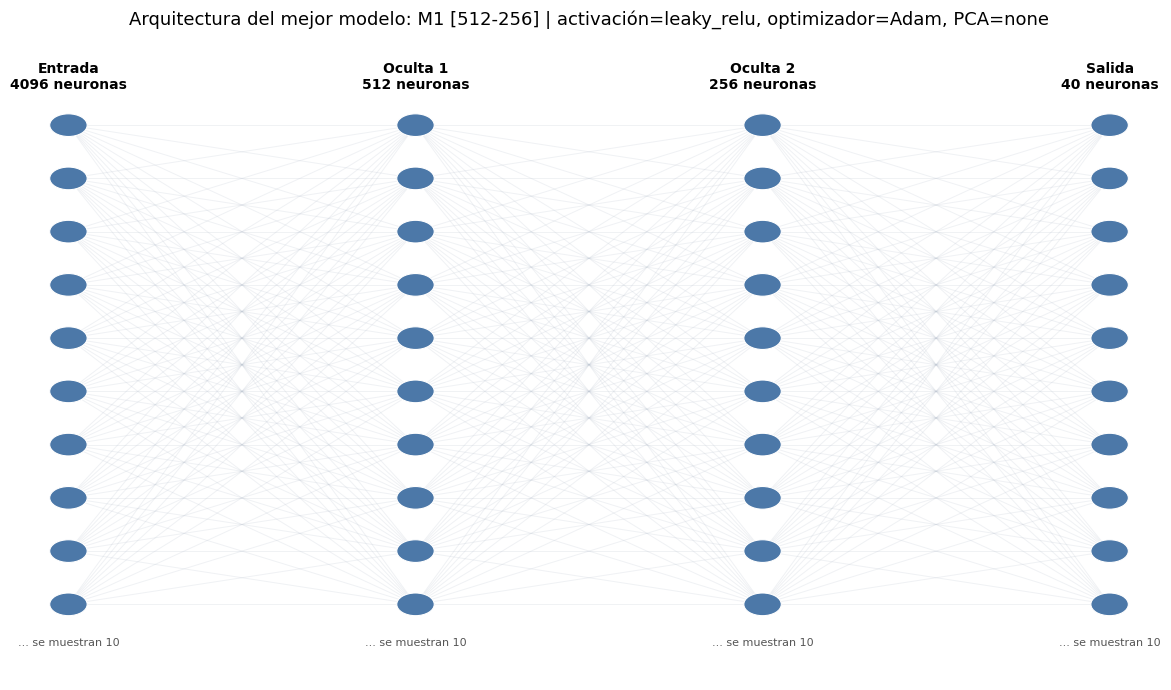

In [42]:
def draw_mlp_architecture(model_info, max_nodes_per_layer=10):
    hidden = model_info["hidden"]
    layer_sizes = [model_info["input_dim"]] + hidden + [40]
    layer_names = ["Entrada"] + [f"Oculta {i}" for i in range(1, len(hidden) + 1)] + ["Salida"]

    fig, ax = plt.subplots(figsize=(max(12, 1.8 * len(layer_sizes)), 7))
    x_positions = np.linspace(0, 1, len(layer_sizes))
    node_positions = []

    for x, size, name in zip(x_positions, layer_sizes, layer_names):
        shown = min(size, max_nodes_per_layer)
        y_positions = np.linspace(0.12, 0.88, shown)
        coords = []
        for y_pos in y_positions:
            circle = plt.Circle((x, y_pos), 0.018, color="#4C78A8", ec="white", lw=0.8, zorder=3)
            ax.add_patch(circle)
            coords.append((x, y_pos))
        node_positions.append(coords)
        ax.text(x, 0.98, f"{name}\n{size} neuronas", ha="center", va="top", fontsize=10, weight="bold")
        if size > shown:
            ax.text(x, 0.05, f"... se muestran {shown}", ha="center", va="bottom", fontsize=8, color="#555")

    for left, right in zip(node_positions[:-1], node_positions[1:]):
        for x1, y1 in left:
            for x2, y2 in right:
                ax.plot([x1, x2], [y1, y2], color="#B9C2CF", alpha=0.22, lw=0.7, zorder=1)

    p = model_info["params"]
    title = (f"Arquitectura del mejor modelo: {model_info['name']} | "
             f"activación={p['activation']}, optimizador={p['optimizer']}, PCA={p['pca']}")
    ax.set_title(title, fontsize=13, pad=18)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0, 1)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("fig_12_network_architecture.png", dpi=150, bbox_inches="tight")
    plt.show()


draw_mlp_architecture(best_test_model)


También se puede mirar cómo el mejor modelo clasifica una imagen concreta del conjunto
de test. La gráfica de barras muestra las 5 clases con mayor probabilidad Softmax.


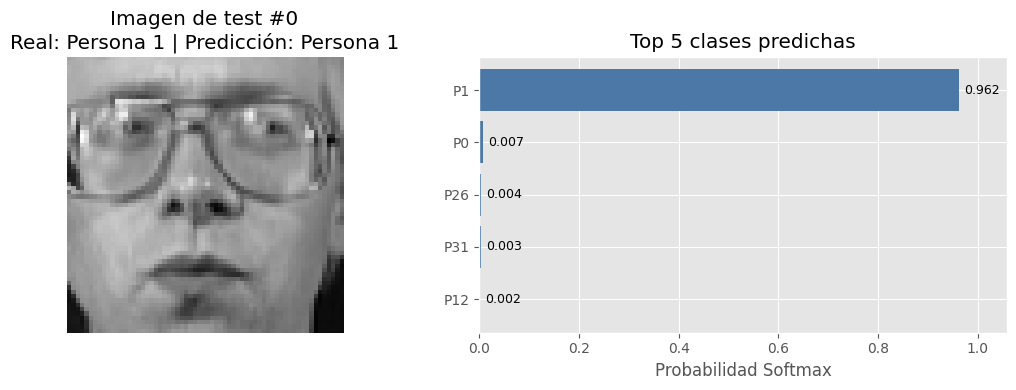

In [43]:
best = best_test_model
_, _, Xte_best = get_feature_tensors(best["pca"])

# Preferimos mostrar un acierto; si no hay aciertos, se muestra la primera muestra.
correct_idxs = np.where(best["preds_test"] == best["labels_test"])[0]
sample_idx = int(correct_idxs[0]) if len(correct_idxs) else 0

best["model"].eval()
with torch.no_grad():
    logits = best["model"](Xte_best[sample_idx].unsqueeze(0))
    probs = torch.softmax(logits, dim=1).squeeze().numpy()

top5 = np.argsort(probs)[-5:][::-1]
true_cls = int(y_test[sample_idx])
pred_cls = int(top5[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(X_test[sample_idx].reshape(64, 64), cmap="gray")
axes[0].set_title(f"Imagen de test #{sample_idx}\nReal: Persona {true_cls} | Predicción: Persona {pred_cls}")
axes[0].axis("off")

axes[1].barh([f"P{c}" for c in top5[::-1]], probs[top5][::-1], color="#4C78A8")
axes[1].set_xlabel("Probabilidad Softmax")
axes[1].set_title("Top 5 clases predichas")
axes[1].set_xlim(0, max(1.0, probs[top5].max() * 1.1))
for i, c in enumerate(top5[::-1]):
    axes[1].text(probs[c] + 0.01, i, f"{probs[c]:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("fig_13_prediction_example.png", dpi=150, bbox_inches="tight")
plt.show()
